MSWX downscaled fsno shape : (8744, 1000)
MSWX base fsno shape: (8744, 1000)
MSWX downscaled hrus shape : (1801, 1801)
MSWX base hrus shape: (1801, 1801)
Same plotting grid: True


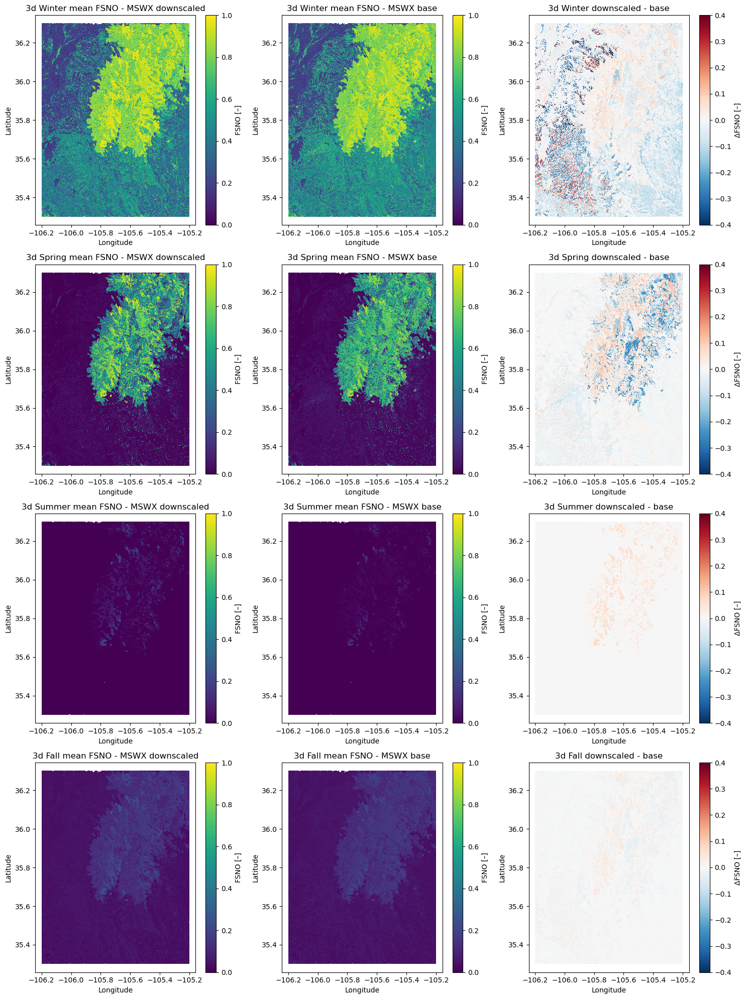

In [9]:
import numpy as np
import netCDF4 as nc
import pandas as pd
import matplotlib.pyplot as plt
import os
import matplotlib.colors as colors
import geospatialtools.gdal_tools as gdal_tools

# Paths
path_mswx_dns = "/scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/experiments/simulations/Precip_MSWX_3h_Snow_Project3_3d_downscale/"
path_mswx = "/scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/experiments/simulations/partition_options/option_3/MSWX_3h_Snow_Project3_3d/"
outputdir = "/scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/validation_plots/Precip_MSWX_Downscaled_forcing_plots"
os.makedirs(outputdir, exist_ok=True)

# clean 2016 file
file_mswx_dns = path_mswx_dns + "output_data/1/2016-01-01.nc"
file_mswx = path_mswx + "output_data/1/2016-01-01.nc"


# HRU rasters
hrus_mswx_dns = gdal_tools.read_raster(path_mswx_dns + "postprocess/hrus.vrt")
cids_mswx_dns = gdal_tools.read_raster(path_mswx_dns + "postprocess/cids.vrt")
meta_mswx_dns = gdal_tools.retrieve_metadata(path_mswx_dns + "postprocess/hrus.vrt")

hrus_mswx = gdal_tools.read_raster(path_mswx + "postprocess/hrus.vrt")
cids_mswx = gdal_tools.read_raster(path_mswx + "postprocess/cids.vrt")
meta_mswx = gdal_tools.retrieve_metadata(path_mswx + "postprocess/hrus.vrt")

buffer = 250

# forcing coordinates
coord_xx0_mswx = np.linspace(meta_mswx["minx"], meta_mswx["maxx"], meta_mswx["nx"])
coord_yy0_mswx = np.linspace(meta_mswx["miny"], meta_mswx["maxy"], meta_mswx["ny"])
coords_x_mswx = coord_xx0_mswx[buffer:len(coord_xx0_mswx)-buffer+1]
coords_y_mswx = coord_yy0_mswx[buffer:len(coord_yy0_mswx)-buffer+1]

coord_xx0_mswx_dns = np.linspace(meta_mswx_dns["minx"], meta_mswx_dns["maxx"], meta_mswx_dns["nx"])
coord_yy0_mswx_dns = np.linspace(meta_mswx_dns["miny"], meta_mswx_dns["maxy"], meta_mswx_dns["ny"])
coords_x_mswx_dns = coord_xx0_mswx_dns[buffer:len(coord_xx0_mswx_dns)-buffer+1]
coords_y_mswx_dns = coord_yy0_mswx_dns[buffer:len(coord_yy0_mswx_dns)-buffer+1]

tmp_mswx = np.full(hrus_mswx.shape, -9999.0, dtype=np.float32)
tmp_mswx_dns = np.full(hrus_mswx_dns.shape, -9999.0, dtype=np.float32)

def place_data(tmp, model, hrus, cids, cid_val):
    out = np.copy(tmp)
    for i in range(out.shape[0]):
        for j in range(out.shape[1]):
            hru = int(hrus[i, j])
            ucid = int(cids[i, j])
            if (hru > 0) and (ucid == cid_val):
                out[i, j] = model[hru - 1]
    return out

def read_fsno(ncfile):
    fp = nc.Dataset(ncfile)
    grp = fp.groups["data"]
    fsno = np.array(grp.variables["fsno"][:])   # (time, hru)
    fp.close()
    return fsno

# Read FSNO
fsno_mswx_dns = read_fsno(file_mswx_dns)
fsno_mswx = read_fsno(file_mswx)

print("MSWX downscaled fsno shape :", fsno_mswx_dns.shape)
print("MSWX base fsno shape:", fsno_mswx.shape)
print("MSWX downscaled hrus shape :", hrus_mswx_dns.shape)
print("MSWX base hrus shape:", hrus_mswx.shape)


# Check compatibility
if fsno_mswx_dns.shape[1] != np.nanmax(hrus_mswx_dns):
    print("Warning: MSWX downscaled HRU count may not match fsno HRU dimension")

if fsno_mswx.shape[1] != np.nanmax(hrus_mswx):
    print("Warning: MSWX base HRU count may not match fsno HRU dimension")

same_grid = (
    hrus_mswx.shape == hrus_mswx_dns.shape and
    meta_mswx["minx"] == meta_mswx_dns["minx"] and
    meta_mswx["maxx"] == meta_mswx_dns["maxx"] and
    meta_mswx["miny"] == meta_mswx_dns["miny"] and
    meta_mswx["maxy"] == meta_mswx_dns["maxy"]
)

print("Same plotting grid:", same_grid)

# same 2016–2018 3-hourly timeline for both forcing
ntime = fsno_mswx.shape[0]
times = pd.date_range("2016-01-01 00:00:00", periods=ntime, freq="3H")


# Seasonal definitions
seasons = ["Winter", "Spring", "Summer", "Fall"]
season_months = {
    "Winter": [12, 1, 2],
    "Spring": [3, 4, 5],
    "Summer": [6, 7, 8],
    "Fall":   [9, 10, 11],
}

# Plot MSWX downscaled vs MSWX base vs Difference
fig, axes = plt.subplots(4, 3, figsize=(15, 20))

norm_fsno = colors.Normalize(vmin=0.0, vmax=1.0)
norm_diff = colors.TwoSlopeNorm(vmin=-0.4, vcenter=0.0, vmax=0.4)

for row, season in enumerate(seasons):
    mask = times.month.isin(season_months[season])

    mswx_dns_mean = np.nanmean(fsno_mswx_dns[mask, :], axis=0)
    mswx_mean = np.nanmean(fsno_mswx[mask, :], axis=0)

    map_mswx_dns = place_data(tmp_mswx_dns, mswx_dns_mean, hrus_mswx_dns, cids_mswx_dns, 1)
    map_mswx = place_data(tmp_mswx, mswx_mean, hrus_mswx, cids_mswx, 1)

    map_mswx_dns = np.ma.masked_where(map_mswx_dns == -9999.0, map_mswx_dns)
    map_mswx = np.ma.masked_where(map_mswx == -9999.0, map_mswx)

    map_mswx_dns = map_mswx_dns[buffer:map_mswx_dns.shape[0]-buffer+1,
                                buffer:map_mswx_dns.shape[1]-buffer+1]
    map_mswx = map_mswx[buffer:map_mswx.shape[0]-buffer+1,
                        buffer:map_mswx.shape[1]-buffer+1]

    # difference only safe if final mapped grids are same shape
    if map_mswx.shape != map_mswx_dns.shape:
        raise ValueError(
            f"Mapped MSWX base and MSWX downscaled grids differ in shape: {map_mswx.shape} vs {map_mswx_dns.shape}"
        )

    diff_mean = map_mswx_dns - map_mswx

    ax0, ax1, ax2 = axes[row, :]

    im0 = ax0.pcolormesh(
        coords_x_mswx_dns, coords_y_mswx_dns, np.flipud(map_mswx_dns),
        cmap="viridis", norm=norm_fsno, shading="auto"
    )
    ax0.set_title(f"3d {season} mean FSNO - MSWX downscaled")
    fig.colorbar(im0, ax=ax0, label="FSNO [–]")

    im1 = ax1.pcolormesh(
        coords_x_mswx, coords_y_mswx, np.flipud(map_mswx),
        cmap="viridis", norm=norm_fsno, shading="auto"
    )
    ax1.set_title(f"3d {season} mean FSNO - MSWX base")
    fig.colorbar(im1, ax=ax1, label="FSNO [–]")

    im2 = ax2.pcolormesh(
        coords_x_mswx_dns, coords_y_mswx_dns, np.flipud(diff_mean),
        cmap="RdBu_r", norm=norm_diff, shading="auto"
    )
    ax2.set_title(f"3d {season} downscaled - base")
    fig.colorbar(im2, ax=ax2, label="ΔFSNO [–]")

    for ax in [ax0, ax1, ax2]:
        ax.set_xlabel("Longitude")
        ax.set_ylabel("Latitude")

plt.tight_layout()
plt.savefig(
    os.path.join(outputdir, "opt_3d seasonal_fsno_MSWX_downscaled_vs_base_2016_2018.png"),
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [1]:
import numpy as np
import netCDF4 as nc
import pandas as pd
import matplotlib.pyplot as plt
import os
import matplotlib.colors as colors
import geospatialtools.gdal_tools as gdal_tools

# ----------------------------
# Paths
# ----------------------------
path_pp = "/scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/experiments/simulations/Precip_MSWX_3h_Snow_Project3_pp_downscale/"
outputdir = "/scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/validation_plots/Precip_MSWX_Downscaled_forcing_plots"
os.makedirs(outputdir, exist_ok=True)

# IMPORTANT:
# use ONLY the rerun file for 2016–2018, not all files in output_data/1
fsno_file = path_pp + "output_data/1/2016-01-01.nc"

# ----------------------------
# Read HRU rasters
# ----------------------------
hrus = gdal_tools.read_raster(path_pp + "postprocess/hrus.vrt")
metad = gdal_tools.retrieve_metadata(path_pp + "postprocess/hrus.vrt")
cids = gdal_tools.read_raster(path_pp + "postprocess/cids.vrt")

buffer = 250

coord_xx0 = np.linspace(metad["minx"], metad["maxx"], metad["nx"])
coord_yy0 = np.linspace(metad["miny"], metad["maxy"], metad["ny"])

coords_x = coord_xx0[buffer:len(coord_xx0) - buffer + 1]
coords_y = coord_yy0[buffer:len(coord_yy0) - buffer + 1]

tmp = np.copy(hrus).astype(np.float32)
tmp[:] = -9999.0

def place_data(tmp, model, hrus, cids, cid_val):
    out = np.copy(tmp)
    for i in range(out.shape[0]):
        for j in range(out.shape[1]):
            hru = int(hrus[i, j])
            ucid = int(cids[i, j])
            if (hru > 0) and (ucid == cid_val):
                out[i, j] = model[hru - 1]
    return out

# ----------------------------
# Read FSNO from 2016–2018 rerun
# ----------------------------
fp = nc.Dataset(fsno_file)
grp = fp.groups["data"]
fsno = np.array(grp.variables["fsno"][:])   # (time, hru)
fp.close()

# This file is already the 2016–2018 run:
ntime = fsno.shape[0]
times = pd.date_range("2016-01-01 00:00:00", periods=ntime, freq="3H")

print(fsno.shape)
print(times.min(), times.max())

# ----------------------------
# Seasonal definitions
# ----------------------------
seasons = ["Winter", "Spring", "Summer", "Fall"]
season_months = {
    "Winter": [12, 1, 2],
    "Spring": [3, 4, 5],
    "Summer": [6, 7, 8],
    "Fall":   [9, 10, 11],
}

# ----------------------------
# Plot 2x2 seasonal mean FSNO
# ----------------------------
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

fsno_norm = colors.Normalize(vmin=0.0, vmax=1.0)

for ax, season in zip(axes, seasons):
    mask = times.month.isin(season_months[season])
    fsno_season = fsno[mask, :]
    fsno_mean = np.nanmean(fsno_season, axis=0)

    final_map = place_data(tmp, fsno_mean, hrus, cids, 1)
    final_map = np.ma.masked_where(final_map == -9999.0, final_map)

    final_map = final_map[
        buffer:final_map.shape[0] - buffer + 1,
        buffer:final_map.shape[1] - buffer + 1
    ]

    im = ax.pcolormesh(
        coords_x,
        coords_y,
        np.flipud(final_map),
        cmap="viridis",
        norm=fsno_norm,
        shading="auto"
    )

    ax.set_title(f"{season} mean FSNO (2016–2018)")
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    fig.colorbar(im, ax=ax, label="FSNO [–]")

plt.tight_layout()
plt.savefig(
    os.path.join(outputdir, "DT_10.png"),
    dpi=300,
    bbox_inches="tight"
)
plt.show()

(8744, 1000)
2016-01-01 00:00:00 2018-12-28 21:00:00


KeyboardInterrupt: 

fsno shape: (8744, 1500)
time range: 2016-01-01 00:00:00 2018-12-28 21:00:00
min HRU in raster for cid=1: 1
max HRU in raster for cid=1: 1499
unique HRUs in raster for cid=1: 1499
number of invalid HRU ids: 0
first few invalid HRUs: []


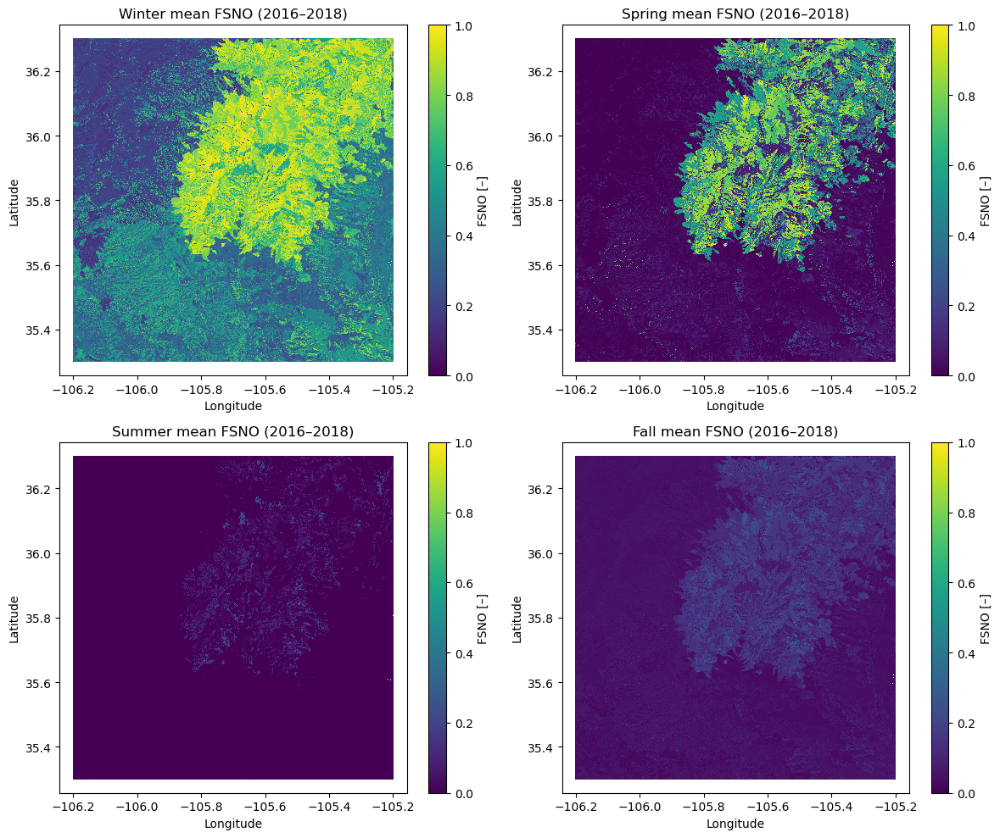

In [11]:
import numpy as np
import netCDF4 as nc
import pandas as pd
import matplotlib.pyplot as plt
import os
import matplotlib.colors as colors
import geospatialtools.gdal_tools as gdal_tools

# ----------------------------
# Paths
# ----------------------------
path_pp = "/scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/experiments/simulations/svf_B5_cl75_Precip_MSWX_3h_Snow_Project3_pp_downscale/"
outputdir = "/scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/validation_plots/Precip_MSWX_Downscaled_forcing_plots"
os.makedirs(outputdir, exist_ok=True)

fsno_file = path_pp + "output_data/1/2016-01-01.nc"

# ----------------------------
# Read HRU rasters
# ----------------------------
hrus = gdal_tools.read_raster(path_pp + "postprocess/hrus.vrt")
metad = gdal_tools.retrieve_metadata(path_pp + "postprocess/hrus.vrt")
cids = gdal_tools.read_raster(path_pp + "postprocess/cids.vrt")

buffer = 250

coord_xx0 = np.linspace(metad["minx"], metad["maxx"], metad["nx"])
coord_yy0 = np.linspace(metad["miny"], metad["maxy"], metad["ny"])

coords_x = coord_xx0[buffer:len(coord_xx0) - buffer + 1]
coords_y = coord_yy0[buffer:len(coord_yy0) - buffer + 1]

tmp = np.copy(hrus).astype(np.float32)
tmp[:] = -9999.0

def place_data(tmp, model, hrus, cids, cid_val):
    out = np.copy(tmp)
    nhru = len(model)

    for i in range(out.shape[0]):
        for j in range(out.shape[1]):
            hru = int(hrus[i, j])
            ucid = int(cids[i, j])

            if (ucid == cid_val) and (hru > 0) and (hru <= nhru):
                out[i, j] = model[hru - 1]

    return out

# ----------------------------
# Read FSNO from 2016–2018 rerun
# ----------------------------
fp = nc.Dataset(fsno_file)
grp = fp.groups["data"]
fsno = np.array(grp.variables["fsno"][:])   # (time, hru)
fp.close()

ntime = fsno.shape[0]
times = pd.date_range("2016-01-01 00:00:00", periods=ntime, freq="3H")

print("fsno shape:", fsno.shape)
print("time range:", times.min(), times.max())

# ----------------------------
# Diagnose HRU mismatch
# ----------------------------
mask_cid1 = (cids == 1) & (hrus > 0)
hru_vals = hrus[mask_cid1].astype(int)

print("min HRU in raster for cid=1:", hru_vals.min())
print("max HRU in raster for cid=1:", hru_vals.max())
print("unique HRUs in raster for cid=1:", len(np.unique(hru_vals)))

bad = np.unique(hru_vals[hru_vals > fsno.shape[1]])
print("number of invalid HRU ids:", len(bad))
print("first few invalid HRUs:", bad[:20])

# ----------------------------
# Seasonal definitions
# ----------------------------
seasons = ["Winter", "Spring", "Summer", "Fall"]
season_months = {
    "Winter": [12, 1, 2],
    "Spring": [3, 4, 5],
    "Summer": [6, 7, 8],
    "Fall":   [9, 10, 11],
}

# ----------------------------
# Plot 2x2 seasonal mean FSNO
# ----------------------------
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

fsno_norm = colors.Normalize(vmin=0.0, vmax=1.0)

for ax, season in zip(axes, seasons):
    mask = times.month.isin(season_months[season])
    fsno_season = fsno[mask, :]
    fsno_mean = np.nanmean(fsno_season, axis=0)

    final_map = place_data(tmp, fsno_mean, hrus, cids, 1)
    final_map = np.ma.masked_where(final_map == -9999.0, final_map)

    final_map = final_map[
        buffer:final_map.shape[0] - buffer + 1,
        buffer:final_map.shape[1] - buffer + 1
    ]

    im = ax.pcolormesh(
        coords_x,
        coords_y,
        np.flipud(final_map),
        cmap="viridis",
        norm=fsno_norm,
        shading="auto"
    )

    ax.set_title(f"{season} mean FSNO (2016–2018)")
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    fig.colorbar(im, ax=ax, label="FSNO [–]")

plt.tight_layout()
plt.savefig(
    os.path.join(outputdir, "1svf_B5_cl5.png"),
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [7]:
import numpy as np
import netCDF4 as nc
import pandas as pd
import matplotlib.pyplot as plt
import os
import matplotlib.colors as colors
import geospatialtools.gdal_tools as gdal_tools

# Paths
path_mswx_dns = "/scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/experiments/simulations/svf_B5_cl75_Precip_MSWX_3h_Snow_Project3_pp_downscale/"
path_mswx = "/scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/experiments/simulations/partition_options/option_3/MSWX_3h_Snow_Project3_pp/"
outputdir = "/scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/validation_plots/Precip_MSWX_Downscaled_forcing_plots"
os.makedirs(outputdir, exist_ok=True)

# clean 2016 file
file_mswx_dns = path_mswx_dns + "output_data/1/2016-01-01.nc"
file_mswx = path_mswx + "output_data/1/2016-01-01.nc"


# HRU rasters
hrus_mswx_dns = gdal_tools.read_raster(path_mswx_dns + "postprocess/hrus.vrt")
cids_mswx_dns = gdal_tools.read_raster(path_mswx_dns + "postprocess/cids.vrt")
meta_mswx_dns = gdal_tools.retrieve_metadata(path_mswx_dns + "postprocess/hrus.vrt")

hrus_mswx = gdal_tools.read_raster(path_mswx + "postprocess/hrus.vrt")
cids_mswx = gdal_tools.read_raster(path_mswx + "postprocess/cids.vrt")
meta_mswx = gdal_tools.retrieve_metadata(path_mswx + "postprocess/hrus.vrt")

buffer = 250

# forcing coordinates
coord_xx0_mswx = np.linspace(meta_mswx["minx"], meta_mswx["maxx"], meta_mswx["nx"])
coord_yy0_mswx = np.linspace(meta_mswx["miny"], meta_mswx["maxy"], meta_mswx["ny"])
coords_x_mswx = coord_xx0_mswx[buffer:len(coord_xx0_mswx)-buffer+1]
coords_y_mswx = coord_yy0_mswx[buffer:len(coord_yy0_mswx)-buffer+1]

coord_xx0_mswx_dns = np.linspace(meta_mswx_dns["minx"], meta_mswx_dns["maxx"], meta_mswx_dns["nx"])
coord_yy0_mswx_dns = np.linspace(meta_mswx_dns["miny"], meta_mswx_dns["maxy"], meta_mswx_dns["ny"])
coords_x_mswx_dns = coord_xx0_mswx_dns[buffer:len(coord_xx0_mswx_dns)-buffer+1]
coords_y_mswx_dns = coord_yy0_mswx_dns[buffer:len(coord_yy0_mswx_dns)-buffer+1]

tmp_mswx = np.full(hrus_mswx.shape, -9999.0, dtype=np.float32)
tmp_mswx_dns = np.full(hrus_mswx_dns.shape, -9999.0, dtype=np.float32)

def place_data(tmp, model, hrus, cids, cid_val):
    out = np.copy(tmp)
    for i in range(out.shape[0]):
        for j in range(out.shape[1]):
            hru = int(hrus[i, j])
            ucid = int(cids[i, j])
            if (hru > 0) and (ucid == cid_val):
                out[i, j] = model[hru - 1]
    return out

def read_fsno(ncfile):
    fp = nc.Dataset(ncfile)
    grp = fp.groups["data"]
    fsno = np.array(grp.variables["fsno"][:])   # (time, hru)
    fp.close()
    return fsno

# Read FSNO
fsno_mswx_dns = read_fsno(file_mswx_dns)
fsno_mswx = read_fsno(file_mswx)

print("MSWX downscaled fsno shape :", fsno_mswx_dns.shape)
print("MSWX base fsno shape:", fsno_mswx.shape)
print("MSWX downscaled hrus shape :", hrus_mswx_dns.shape)
print("MSWX base hrus shape:", hrus_mswx.shape)


# Check compatibility
if fsno_mswx_dns.shape[1] != np.nanmax(hrus_mswx_dns):
    print("Warning: MSWX downscaled HRU count may not match fsno HRU dimension")

if fsno_mswx.shape[1] != np.nanmax(hrus_mswx):
    print("Warning: MSWX base HRU count may not match fsno HRU dimension")

same_grid = (
    hrus_mswx.shape == hrus_mswx_dns.shape and
    meta_mswx["minx"] == meta_mswx_dns["minx"] and
    meta_mswx["maxx"] == meta_mswx_dns["maxx"] and
    meta_mswx["miny"] == meta_mswx_dns["miny"] and
    meta_mswx["maxy"] == meta_mswx_dns["maxy"]
)

print("Same plotting grid:", same_grid)

# same 2016–2018 3-hourly timeline for both forcing
ntime = fsno_mswx.shape[0]
times = pd.date_range("2016-01-01 00:00:00", periods=ntime, freq="3H")


# Seasonal definitions
seasons = ["Winter", "Spring", "Summer", "Fall"]
season_months = {
    "Winter": [12, 1, 2],
    "Spring": [3, 4, 5],
    "Summer": [6, 7, 8],
    "Fall":   [9, 10, 11],
}

# Plot MSWX downscaled vs MSWX base vs Difference
fig, axes = plt.subplots(4, 3, figsize=(15, 20))

norm_fsno = colors.Normalize(vmin=0.0, vmax=1.0)
norm_diff = colors.TwoSlopeNorm(vmin=-0.4, vcenter=0.0, vmax=0.4)

for row, season in enumerate(seasons):
    mask = times.month.isin(season_months[season])

    mswx_dns_mean = np.nanmean(fsno_mswx_dns[mask, :], axis=0)
    mswx_mean = np.nanmean(fsno_mswx[mask, :], axis=0)

    map_mswx_dns = place_data(tmp_mswx_dns, mswx_dns_mean, hrus_mswx_dns, cids_mswx_dns, 1)
    map_mswx = place_data(tmp_mswx, mswx_mean, hrus_mswx, cids_mswx, 1)

    map_mswx_dns = np.ma.masked_where(map_mswx_dns == -9999.0, map_mswx_dns)
    map_mswx = np.ma.masked_where(map_mswx == -9999.0, map_mswx)

    map_mswx_dns = map_mswx_dns[buffer:map_mswx_dns.shape[0]-buffer+1,
                                buffer:map_mswx_dns.shape[1]-buffer+1]
    map_mswx = map_mswx[buffer:map_mswx.shape[0]-buffer+1,
                        buffer:map_mswx.shape[1]-buffer+1]

    # difference only safe if final mapped grids are same shape
    if map_mswx.shape != map_mswx_dns.shape:
        raise ValueError(
            f"Mapped MSWX base and MSWX downscaled grids differ in shape: {map_mswx.shape} vs {map_mswx_dns.shape}"
        )

    diff_mean = map_mswx_dns - map_mswx

    ax0, ax1, ax2 = axes[row, :]

    im0 = ax0.pcolormesh(
        coords_x_mswx_dns, coords_y_mswx_dns, np.flipud(map_mswx_dns),
        cmap="viridis", norm=norm_fsno, shading="auto"
    )
    ax0.set_title(f"pp {season} mean FSNO - MSWX downscaled")
    fig.colorbar(im0, ax=ax0, label="FSNO [–]")

    im1 = ax1.pcolormesh(
        coords_x_mswx, coords_y_mswx, np.flipud(map_mswx),
        cmap="viridis", norm=norm_fsno, shading="auto"
    )
    ax1.set_title(f"pp {season} mean FSNO - MSWX base")
    fig.colorbar(im1, ax=ax1, label="FSNO [–]")

    im2 = ax2.pcolormesh(
        coords_x_mswx_dns, coords_y_mswx_dns, np.flipud(diff_mean),
        cmap="RdBu_r", norm=norm_diff, shading="auto"
    )
    ax2.set_title(f"pp {season} downscaled - base")
    fig.colorbar(im2, ax=ax2, label="ΔFSNO [–]")

    for ax in [ax0, ax1, ax2]:
        ax.set_xlabel("Longitude")
        ax.set_ylabel("Latitude")

plt.tight_layout()
plt.savefig(
    os.path.join(outputdir, "SW_dwnscale_opt_pp seasonal_fsno_MSWX_downscaled_vs_base_2016_2018.png"),
    dpi=300,
    bbox_inches="tight"
)
plt.show()

OSError: [Errno -101] NetCDF: HDF error: b'/scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/experiments/simulations/svf_B5_cl75_Precip_MSWX_3h_Snow_Project3_pp_downscale/output_data/1/2016-01-01.nc'

In [6]:
import xarray as xr

path = "/scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/data/snow_experiment/data/cids/1/backup_forcing/NLDAS/"
#path = "/scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/data/cids/1/"

ds = xr.open_dataset(path + "swdown.nc", decode_times=False)
print(ds)
print(ds['swdown'].attrs)

<xarray.Dataset>
Dimensions:  (t: 32128, lat: 16, lon: 16)
Coordinates:
  * lon      (lon) float64 -106.4 -106.3 -106.2 -106.1 ... -105.1 -105.0 -104.9
  * lat      (lat) float64 35.1 35.2 35.3 35.4 35.5 ... 36.2 36.3 36.4 36.5 36.6
  * t        (t) float64 0.0 1.0 2.0 3.0 ... 3.212e+04 3.213e+04 3.213e+04
Data variables:
    swdown   (t, lat, lon) float32 ...
{'long_name': 'swdown', 'units': 'W m-2', 'description': '3-hour mean downward shortwave radiation from NLDAS', 'source': 'NLDAS SWdown aggregated from hourly to 3-hourly and interpolated to HydroBlocks grid'}


In [7]:
import xarray as xr
import rasterio
import numpy as np

forcing_path = "/scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/data/cids/1/swdown.nc"
grid_path = "/scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/data/cids/1/dem_latlon.tif"

# -------------------------
# 1. Open forcing
# -------------------------
ds = xr.open_dataset(forcing_path, decode_times=False)

print("FORCING DATASET")
print(ds)
print()

lat = ds["lat"].values
lon = ds["lon"].values

print("Forcing shape (lat, lon):", len(lat), len(lon))
print("Forcing lat range:", lat.min(), "to", lat.max())
print("Forcing lon range:", lon.min(), "to", lon.max())
print("Forcing dlat:", np.mean(np.diff(lat)))
print("Forcing dlon:", np.mean(np.diff(lon)))
print()

# -------------------------
# 2. Open HydroBlocks raster grid
# -------------------------
with rasterio.open(grid_path) as src:
    print("HYDROBLOCKS GRID")
    print("Raster shape (rows, cols):", src.height, src.width)
    print("Bounds:", src.bounds)
    print("Resolution:", src.res)
    print("CRS:", src.crs)

FORCING DATASET
<xarray.Dataset>
Dimensions:  (lon: 16, lat: 16, t: 32128)
Coordinates:
  * lon      (lon) float64 -106.4 -106.3 -106.2 -106.1 ... -105.1 -105.0 -104.9
  * lat      (lat) float64 35.1 35.2 35.3 35.4 35.5 ... 36.2 36.3 36.4 36.5 36.6
  * t        (t) float64 0.0 1.0 2.0 3.0 ... 3.212e+04 3.213e+04 3.213e+04
Data variables:
    swdown   (t, lat, lon) float32 ...

Forcing shape (lat, lon): 16 16
Forcing lat range: 35.099998474121094 to 36.5999755859375
Forcing lon range: -106.39999771118164 to -104.90002059936523
Forcing dlat: 0.09999847412109375
Forcing dlon: 0.09999847412109375

HYDROBLOCKS GRID
Raster shape (rows, cols): 1801 1801
Bounds: BoundingBox(left=-106.45041666666549, bottom=35.049583333332606, right=-104.94958333333221, top=36.55041666666588)
Resolution: (0.0008333333333333014, 0.0008333333333333014)
CRS: EPSG:4326


In [11]:
import numpy as np

# Get coordinates
lat = ds['lat'].values
lon = ds['lon'].values

# ----------------------------
# 1. Domain bounds
# ----------------------------
lat_min, lat_max = lat.min(), lat.max()
lon_min, lon_max = lon.min(), lon.max()

print("Latitude range:", lat_min, "to", lat_max)
print("Longitude range:", lon_min, "to", lon_max)

# ----------------------------
# 2. Resolution
# ----------------------------
dlat = np.mean(np.diff(lat))
dlon = np.mean(np.diff(lon))

print("Lat resolution (deg):", dlat)
print("Lon resolution (deg):", dlon)

# ----------------------------
# 3. Convert to km (approx)
# ----------------------------
# 1 degree latitude ≈ 111 km
lat_km = dlat * 111

# longitude depends on latitude
mean_lat = np.mean(lat)
lon_km = dlon * 111 * np.cos(np.deg2rad(mean_lat))

print("Lat resolution (km):", lat_km)
print("Lon resolution (km):", lon_km)

# ----------------------------
# 4. Domain size in km
# ----------------------------
domain_lat_km = (lat_max - lat_min) * 111
domain_lon_km = (lon_max - lon_min) * 111 * np.cos(np.deg2rad(mean_lat))

print("Domain size (km):")
print("  Lat:", domain_lat_km)
print("  Lon:", domain_lon_km)

Latitude range: 35.099998474121094 to 36.5999755859375
Longitude range: -106.39999771118164 to -104.90002059936523
Lat resolution (deg): 0.09999847412109375
Lon resolution (deg): 0.09999847412109375
Lat resolution (km): 11.099830627441406
Lon resolution (km): 8.997002911853173
Domain size (km):
  Lat: 166.4974594116211
  Lon: 134.9550436777976


fsno shape: (8744, 2000)
time range: 2016-01-01 00:00:00 2018-12-28 21:00:00
min HRU in raster for cid=1: 1
max HRU in raster for cid=1: 1999
unique HRUs in raster for cid=1: 1999
number of invalid HRU ids: 0
first few invalid HRUs: []


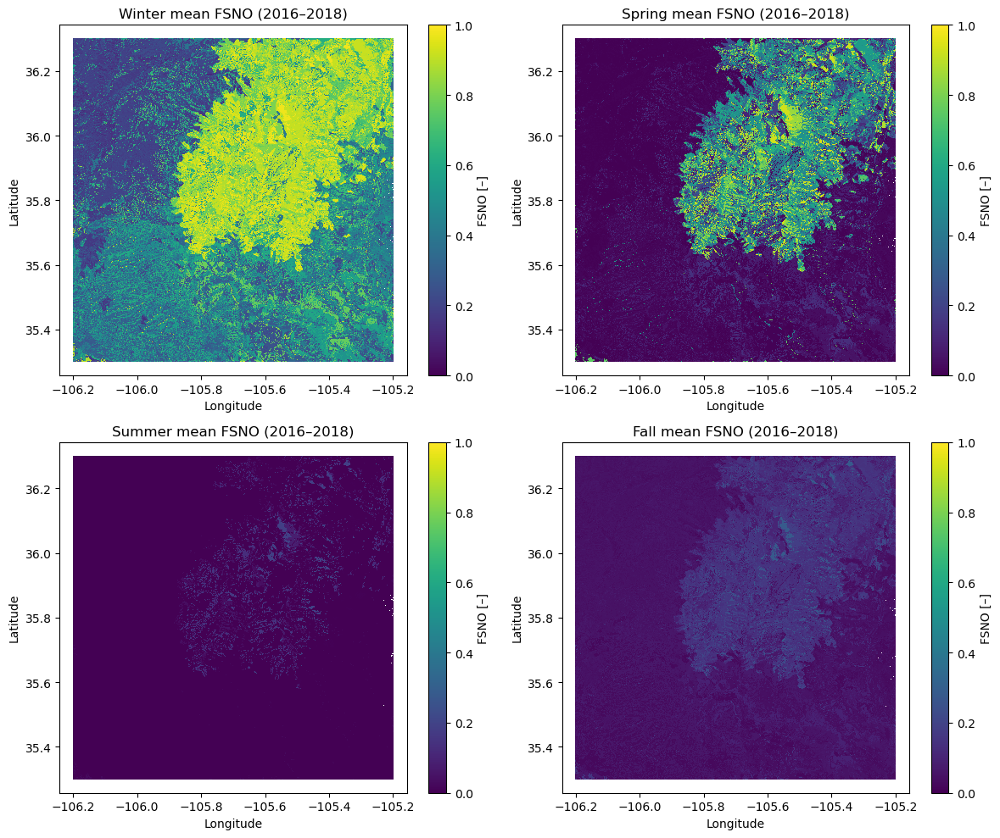

In [5]:
import numpy as np
import netCDF4 as nc
import pandas as pd
import matplotlib.pyplot as plt
import os
import matplotlib.colors as colors
import geospatialtools.gdal_tools as gdal_tools

# ----------------------------
# Paths
# ----------------------------
path_pp = "/scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/experiments/simulations/svf_B5_cl100_Precip_MSWX_3h_Snow_Project3_pp_downscale/"
outputdir = "/scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/validation_plots/Precip_MSWX_Downscaled_forcing_plots"
os.makedirs(outputdir, exist_ok=True)

fsno_file = path_pp + "output_data/1/2016-01-01.nc"

# ----------------------------
# Read HRU rasters
# ----------------------------
hrus = gdal_tools.read_raster(path_pp + "postprocess/hrus.vrt")
metad = gdal_tools.retrieve_metadata(path_pp + "postprocess/hrus.vrt")
cids = gdal_tools.read_raster(path_pp + "postprocess/cids.vrt")

buffer = 250

coord_xx0 = np.linspace(metad["minx"], metad["maxx"], metad["nx"])
coord_yy0 = np.linspace(metad["miny"], metad["maxy"], metad["ny"])

coords_x = coord_xx0[buffer:len(coord_xx0) - buffer + 1]
coords_y = coord_yy0[buffer:len(coord_yy0) - buffer + 1]

tmp = np.copy(hrus).astype(np.float32)
tmp[:] = -9999.0

def place_data(tmp, model, hrus, cids, cid_val):
    out = np.copy(tmp)
    nhru = len(model)

    for i in range(out.shape[0]):
        for j in range(out.shape[1]):
            hru = int(hrus[i, j])
            ucid = int(cids[i, j])

            if (ucid == cid_val) and (hru > 0) and (hru <= nhru):
                out[i, j] = model[hru - 1]

    return out

# ----------------------------
# Read FSNO from 2016–2018 rerun
# ----------------------------
fp = nc.Dataset(fsno_file)
grp = fp.groups["data"]
fsno = np.array(grp.variables["fsno"][:])   # (time, hru)
fp.close()

ntime = fsno.shape[0]
times = pd.date_range("2016-01-01 00:00:00", periods=ntime, freq="3H")

print("fsno shape:", fsno.shape)
print("time range:", times.min(), times.max())

# ----------------------------
# Diagnose HRU mismatch
# ----------------------------
mask_cid1 = (cids == 1) & (hrus > 0)
hru_vals = hrus[mask_cid1].astype(int)

print("min HRU in raster for cid=1:", hru_vals.min())
print("max HRU in raster for cid=1:", hru_vals.max())
print("unique HRUs in raster for cid=1:", len(np.unique(hru_vals)))

bad = np.unique(hru_vals[hru_vals > fsno.shape[1]])
print("number of invalid HRU ids:", len(bad))
print("first few invalid HRUs:", bad[:20])

# ----------------------------
# Seasonal definitions
# ----------------------------
seasons = ["Winter", "Spring", "Summer", "Fall"]
season_months = {
    "Winter": [12, 1, 2],
    "Spring": [3, 4, 5],
    "Summer": [6, 7, 8],
    "Fall":   [9, 10, 11],
}

# ----------------------------
# Plot 2x2 seasonal mean FSNO
# ----------------------------
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

fsno_norm = colors.Normalize(vmin=0.0, vmax=1.0)

for ax, season in zip(axes, seasons):
    mask = times.month.isin(season_months[season])
    fsno_season = fsno[mask, :]
    fsno_mean = np.nanmean(fsno_season, axis=0)

    final_map = place_data(tmp, fsno_mean, hrus, cids, 1)
    final_map = np.ma.masked_where(final_map == -9999.0, final_map)

    final_map = final_map[
        buffer:final_map.shape[0] - buffer + 1,
        buffer:final_map.shape[1] - buffer + 1
    ]

    im = ax.pcolormesh(
        coords_x,
        coords_y,
        np.flipud(final_map),
        cmap="viridis",
        norm=fsno_norm,
        shading="auto"
    )

    ax.set_title(f"{season} mean FSNO (2016–2018)")
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    fig.colorbar(im, ax=ax, label="FSNO [–]")

plt.tight_layout()
plt.savefig(
    os.path.join(outputdir, "B5_cl100_Precip_MSWX_3h_Snow_Project3_pp_downscale.png"),
    dpi=300,
    bbox_inches="tight"
)
plt.show()

fsno shape: (8744, 1500)
time range: 2016-01-01 00:00:00 2018-12-28 21:00:00
min HRU in raster for cid=1: 1
max HRU in raster for cid=1: 1499
unique HRUs in raster for cid=1: 1499
number of invalid HRU ids: 0
first few invalid HRUs: []


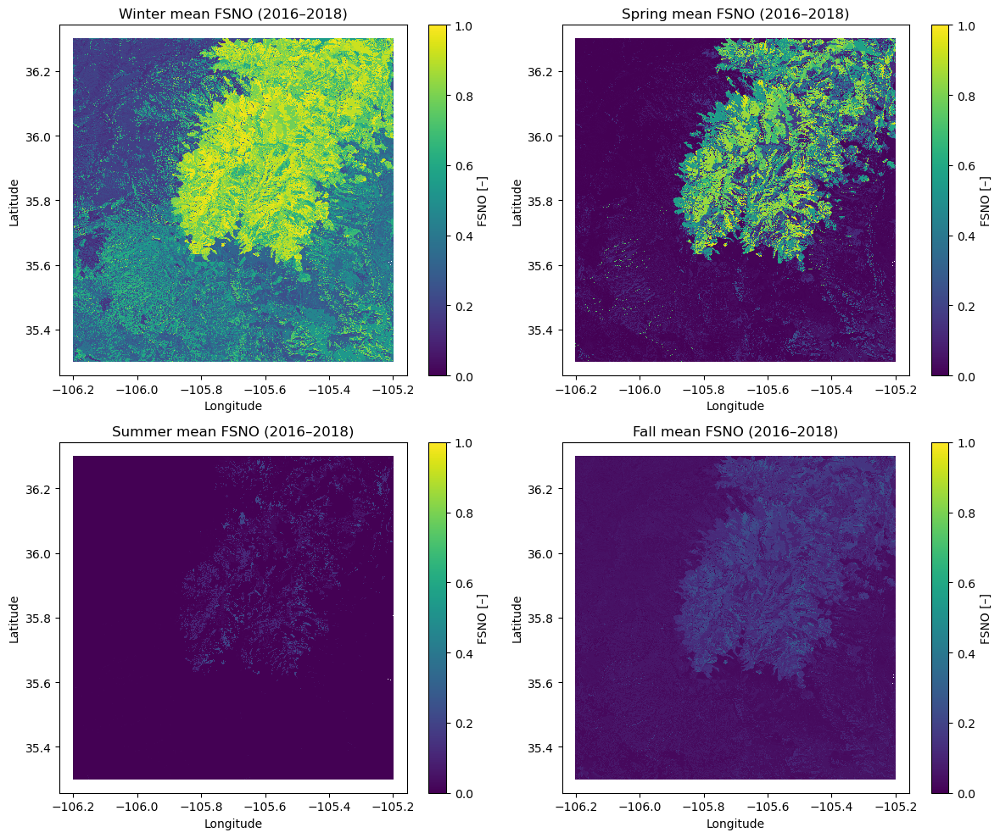

In [6]:
import numpy as np
import netCDF4 as nc
import pandas as pd
import matplotlib.pyplot as plt
import os
import matplotlib.colors as colors
import geospatialtools.gdal_tools as gdal_tools

# ----------------------------
# Paths
# ----------------------------
path_pp = "/scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/experiments/simulations/svf_B5_cl100_Precip_MSWX_3h_Snow_Project3_3d_downscale/"
outputdir = "/scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/validation_plots/Precip_MSWX_Downscaled_forcing_plots"
os.makedirs(outputdir, exist_ok=True)

fsno_file = path_pp + "output_data/1/2016-01-01.nc"

# ----------------------------
# Read HRU rasters
# ----------------------------
hrus = gdal_tools.read_raster(path_pp + "postprocess/hrus.vrt")
metad = gdal_tools.retrieve_metadata(path_pp + "postprocess/hrus.vrt")
cids = gdal_tools.read_raster(path_pp + "postprocess/cids.vrt")

buffer = 250

coord_xx0 = np.linspace(metad["minx"], metad["maxx"], metad["nx"])
coord_yy0 = np.linspace(metad["miny"], metad["maxy"], metad["ny"])

coords_x = coord_xx0[buffer:len(coord_xx0) - buffer + 1]
coords_y = coord_yy0[buffer:len(coord_yy0) - buffer + 1]

tmp = np.copy(hrus).astype(np.float32)
tmp[:] = -9999.0

def place_data(tmp, model, hrus, cids, cid_val):
    out = np.copy(tmp)
    nhru = len(model)

    for i in range(out.shape[0]):
        for j in range(out.shape[1]):
            hru = int(hrus[i, j])
            ucid = int(cids[i, j])

            if (ucid == cid_val) and (hru > 0) and (hru <= nhru):
                out[i, j] = model[hru - 1]

    return out

# ----------------------------
# Read FSNO from 2016–2018 rerun
# ----------------------------
fp = nc.Dataset(fsno_file)
grp = fp.groups["data"]
fsno = np.array(grp.variables["fsno"][:])   # (time, hru)
fp.close()

ntime = fsno.shape[0]
times = pd.date_range("2016-01-01 00:00:00", periods=ntime, freq="3H")

print("fsno shape:", fsno.shape)
print("time range:", times.min(), times.max())

# ----------------------------
# Diagnose HRU mismatch
# ----------------------------
mask_cid1 = (cids == 1) & (hrus > 0)
hru_vals = hrus[mask_cid1].astype(int)

print("min HRU in raster for cid=1:", hru_vals.min())
print("max HRU in raster for cid=1:", hru_vals.max())
print("unique HRUs in raster for cid=1:", len(np.unique(hru_vals)))

bad = np.unique(hru_vals[hru_vals > fsno.shape[1]])
print("number of invalid HRU ids:", len(bad))
print("first few invalid HRUs:", bad[:20])

# ----------------------------
# Seasonal definitions
# ----------------------------
seasons = ["Winter", "Spring", "Summer", "Fall"]
season_months = {
    "Winter": [12, 1, 2],
    "Spring": [3, 4, 5],
    "Summer": [6, 7, 8],
    "Fall":   [9, 10, 11],
}

# ----------------------------
# Plot 2x2 seasonal mean FSNO
# ----------------------------
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

fsno_norm = colors.Normalize(vmin=0.0, vmax=1.0)

for ax, season in zip(axes, seasons):
    mask = times.month.isin(season_months[season])
    fsno_season = fsno[mask, :]
    fsno_mean = np.nanmean(fsno_season, axis=0)

    final_map = place_data(tmp, fsno_mean, hrus, cids, 1)
    final_map = np.ma.masked_where(final_map == -9999.0, final_map)

    final_map = final_map[
        buffer:final_map.shape[0] - buffer + 1,
        buffer:final_map.shape[1] - buffer + 1
    ]

    im = ax.pcolormesh(
        coords_x,
        coords_y,
        np.flipud(final_map),
        cmap="viridis",
        norm=fsno_norm,
        shading="auto"
    )

    ax.set_title(f"{season} mean FSNO (2016–2018)")
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    fig.colorbar(im, ax=ax, label="FSNO [–]")

plt.tight_layout()
plt.savefig(
    os.path.join(outputdir, "B5_cl100_Precip_MSWX_3h_Snow_Project3_3d_downscale.png"),
    dpi=300,
    bbox_inches="tight"
)
plt.show()

fsno shape: (8744, 800)
time range: 2016-01-01 00:00:00 2018-12-28 21:00:00
min HRU in raster for cid=1: 1
max HRU in raster for cid=1: 799
unique HRUs in raster for cid=1: 799
number of invalid HRU ids: 0
first few invalid HRUs: []


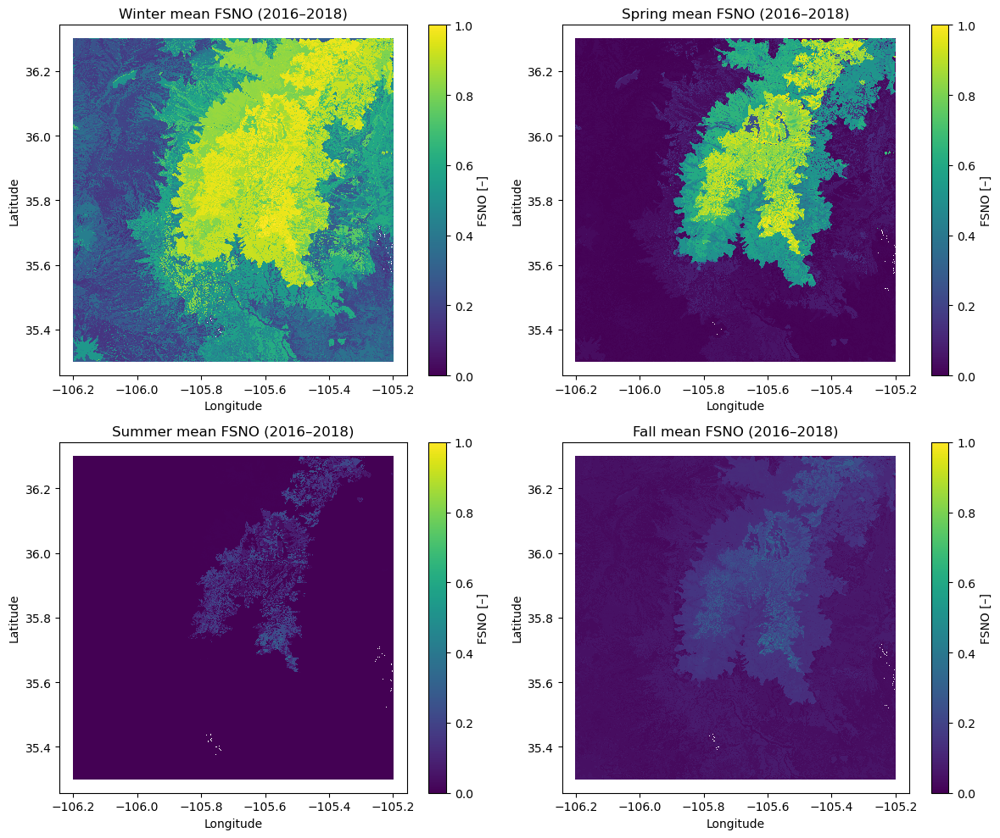

In [18]:
import numpy as np
import netCDF4 as nc
import pandas as pd
import matplotlib.pyplot as plt
import os
import matplotlib.colors as colors
import geospatialtools.gdal_tools as gdal_tools

# ----------------------------
# Paths
# ----------------------------
path_pp = "/scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/experiments/simulations/SB10_B25_cl50_MSWX_3h_Snow_Project3_septiles_downscale/"
outputdir = "/scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/validation_plots/septiles_Precip_MSWX_Downscaled_forcing_plots"
os.makedirs(outputdir, exist_ok=True)

fsno_file = path_pp + "output_data/1/2016-01-01.nc"

# ----------------------------
# Read HRU rasters
# ----------------------------
hrus = gdal_tools.read_raster(path_pp + "postprocess/hrus.vrt")
metad = gdal_tools.retrieve_metadata(path_pp + "postprocess/hrus.vrt")
cids = gdal_tools.read_raster(path_pp + "postprocess/cids.vrt")

buffer = 250

coord_xx0 = np.linspace(metad["minx"], metad["maxx"], metad["nx"])
coord_yy0 = np.linspace(metad["miny"], metad["maxy"], metad["ny"])

coords_x = coord_xx0[buffer:len(coord_xx0) - buffer + 1]
coords_y = coord_yy0[buffer:len(coord_yy0) - buffer + 1]

tmp = np.copy(hrus).astype(np.float32)
tmp[:] = -9999.0

def place_data(tmp, model, hrus, cids, cid_val):
    out = np.copy(tmp)
    nhru = len(model)

    for i in range(out.shape[0]):
        for j in range(out.shape[1]):
            hru = int(hrus[i, j])
            ucid = int(cids[i, j])

            if (ucid == cid_val) and (hru > 0) and (hru <= nhru):
                out[i, j] = model[hru - 1]

    return out

# ----------------------------
# Read FSNO from 2016–2018 rerun
# ----------------------------
fp = nc.Dataset(fsno_file)
grp = fp.groups["data"]
fsno = np.array(grp.variables["fsno"][:])   # (time, hru)
fp.close()

ntime = fsno.shape[0]
times = pd.date_range("2016-01-01 00:00:00", periods=ntime, freq="3H")

print("fsno shape:", fsno.shape)
print("time range:", times.min(), times.max())

# ----------------------------
# Diagnose HRU mismatch
# ----------------------------
mask_cid1 = (cids == 1) & (hrus > 0)
hru_vals = hrus[mask_cid1].astype(int)

print("min HRU in raster for cid=1:", hru_vals.min())
print("max HRU in raster for cid=1:", hru_vals.max())
print("unique HRUs in raster for cid=1:", len(np.unique(hru_vals)))

bad = np.unique(hru_vals[hru_vals > fsno.shape[1]])
print("number of invalid HRU ids:", len(bad))
print("first few invalid HRUs:", bad[:20])

# ----------------------------
# Seasonal definitions
# ----------------------------
seasons = ["Winter", "Spring", "Summer", "Fall"]
season_months = {
    "Winter": [12, 1, 2],
    "Spring": [3, 4, 5],
    "Summer": [6, 7, 8],
    "Fall":   [9, 10, 11],
}

# ----------------------------
# Plot 2x2 seasonal mean FSNO
# ----------------------------
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

fsno_norm = colors.Normalize(vmin=0.0, vmax=1.0)

for ax, season in zip(axes, seasons):
    mask = times.month.isin(season_months[season])
    fsno_season = fsno[mask, :]
    fsno_mean = np.nanmean(fsno_season, axis=0)

    final_map = place_data(tmp, fsno_mean, hrus, cids, 1)
    final_map = np.ma.masked_where(final_map == -9999.0, final_map)

    final_map = final_map[
        buffer:final_map.shape[0] - buffer + 1,
        buffer:final_map.shape[1] - buffer + 1
    ]

    im = ax.pcolormesh(
        coords_x,
        coords_y,
        np.flipud(final_map),
        cmap="viridis",
        norm=fsno_norm,
        shading="auto"
    )

    ax.set_title(f"{season} mean FSNO (2016–2018)")
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    fig.colorbar(im, ax=ax, label="FSNO [–]")

plt.tight_layout()
plt.savefig(
    os.path.join(outputdir, "21SB10_C25_cl50_MSWX_3h_Snow_Project3_septiles_downscale.png"),
    dpi=300,
    bbox_inches="tight"
)
plt.show()

fsno shape: (8744, 2000)
time range: 2016-01-01 00:00:00 2018-12-28 21:00:00
min HRU in raster for cid=1: 1
max HRU in raster for cid=1: 1999
unique HRUs in raster for cid=1: 1999
number of invalid HRU ids: 0
first few invalid HRUs: []


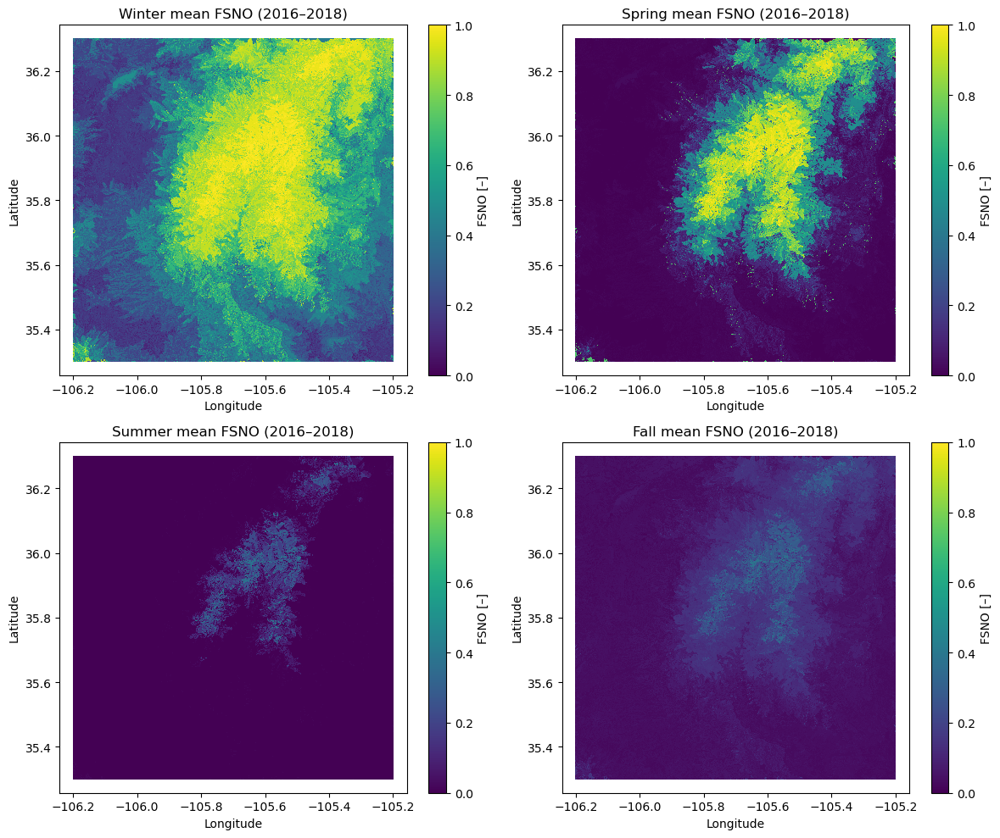

In [6]:
import numpy as np
import netCDF4 as nc
import pandas as pd
import matplotlib.pyplot as plt
import os
import matplotlib.colors as colors
import geospatialtools.gdal_tools as gdal_tools

# ----------------------------
# Paths
# ----------------------------
path_pp = "/scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/experiments/simulations/SB10_B25_cl50_MSWX_3h_Snow_Project3_septiles_downscale/"
outputdir = "/scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/validation_plots/septiles_Precip_MSWX_Downscaled_forcing_plots"
os.makedirs(outputdir, exist_ok=True)

fsno_file = path_pp + "output_data/1/2016-01-01.nc"

# ----------------------------
# Read HRU rasters
# ----------------------------
hrus = gdal_tools.read_raster(path_pp + "postprocess/hrus.vrt")
metad = gdal_tools.retrieve_metadata(path_pp + "postprocess/hrus.vrt")
cids = gdal_tools.read_raster(path_pp + "postprocess/cids.vrt")

buffer = 250

coord_xx0 = np.linspace(metad["minx"], metad["maxx"], metad["nx"])
coord_yy0 = np.linspace(metad["miny"], metad["maxy"], metad["ny"])

coords_x = coord_xx0[buffer:len(coord_xx0) - buffer + 1]
coords_y = coord_yy0[buffer:len(coord_yy0) - buffer + 1]

tmp = np.copy(hrus).astype(np.float32)
tmp[:] = -9999.0

def place_data(tmp, model, hrus, cids, cid_val):
    out = np.copy(tmp)
    nhru = len(model)

    for i in range(out.shape[0]):
        for j in range(out.shape[1]):
            hru = int(hrus[i, j])
            ucid = int(cids[i, j])

            if (ucid == cid_val) and (hru > 0) and (hru <= nhru):
                out[i, j] = model[hru - 1]

    return out

# ----------------------------
# Read FSNO from 2016–2018 rerun
# ----------------------------
fp = nc.Dataset(fsno_file)
grp = fp.groups["data"]
fsno = np.array(grp.variables["fsno"][:])   # (time, hru)
fp.close()

ntime = fsno.shape[0]
times = pd.date_range("2016-01-01 00:00:00", periods=ntime, freq="3H")

print("fsno shape:", fsno.shape)
print("time range:", times.min(), times.max())

# ----------------------------
# Diagnose HRU mismatch
# ----------------------------
mask_cid1 = (cids == 1) & (hrus > 0)
hru_vals = hrus[mask_cid1].astype(int)

print("min HRU in raster for cid=1:", hru_vals.min())
print("max HRU in raster for cid=1:", hru_vals.max())
print("unique HRUs in raster for cid=1:", len(np.unique(hru_vals)))

bad = np.unique(hru_vals[hru_vals > fsno.shape[1]])
print("number of invalid HRU ids:", len(bad))
print("first few invalid HRUs:", bad[:20])

# ----------------------------
# Seasonal definitions
# ----------------------------
seasons = ["Winter", "Spring", "Summer", "Fall"]
season_months = {
    "Winter": [12, 1, 2],
    "Spring": [3, 4, 5],
    "Summer": [6, 7, 8],
    "Fall":   [9, 10, 11],
}

# ----------------------------
# Plot 2x2 seasonal mean FSNO
# ----------------------------
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

fsno_norm = colors.Normalize(vmin=0.0, vmax=1.0)

for ax, season in zip(axes, seasons):
    mask = times.month.isin(season_months[season])
    fsno_season = fsno[mask, :]
    fsno_mean = np.nanmean(fsno_season, axis=0)

    final_map = place_data(tmp, fsno_mean, hrus, cids, 1)
    final_map = np.ma.masked_where(final_map == -9999.0, final_map)

    final_map = final_map[
        buffer:final_map.shape[0] - buffer + 1,
        buffer:final_map.shape[1] - buffer + 1
    ]

    im = ax.pcolormesh(
        coords_x,
        coords_y,
        np.flipud(final_map),
        cmap="viridis",
        norm=fsno_norm,
        shading="auto"
    )

    ax.set_title(f"{season} mean FSNO (2016–2018)")
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    fig.colorbar(im, ax=ax, label="FSNO [–]")

plt.tight_layout()
plt.savefig(
    os.path.join(outputdir, "24SB10_C25_cl50_MSWX_3h_Snow_Project3_septiles_downscale.png"),
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [7]:
import xarray as xr

#path = "/scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/data/snow_experiment/data/cids/1/backup_forcing/NLDAS/"
path = "/scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/data/cids/1/"

ds = xr.open_dataset(path + "swdown.nc", decode_times=False)
print(ds)
print(ds['swdown'].attrs)

<xarray.Dataset>
Dimensions:  (t: 32128, lat: 16, lon: 16)
Coordinates:
  * t        (t) float64 0.0 1.0 2.0 3.0 ... 3.212e+04 3.213e+04 3.213e+04
  * lat      (lat) float64 35.1 35.2 35.3 35.4 35.5 ... 36.2 36.3 36.4 36.5 36.6
  * lon      (lon) float64 -106.4 -106.3 -106.2 -106.1 ... -105.1 -105.0 -104.9
Data variables:
    swdown   (t, lat, lon) float32 ...
{'long_name': 'swdown', 'units': 'W m-2', 'description': '3-hour mean downward shortwave radiation from NLDAS', 'source': 'NLDAS SWdown aggregated from hourly to 3-hourly and interpolated to HydroBlocks grid'}


fsno shape: (8744, 1000)
time range: 2016-01-01 00:00:00 2018-12-28 21:00:00
min HRU in raster for cid=1: 1
max HRU in raster for cid=1: 999
unique HRUs in raster for cid=1: 999
number of invalid HRU ids: 0
first few invalid HRUs: []


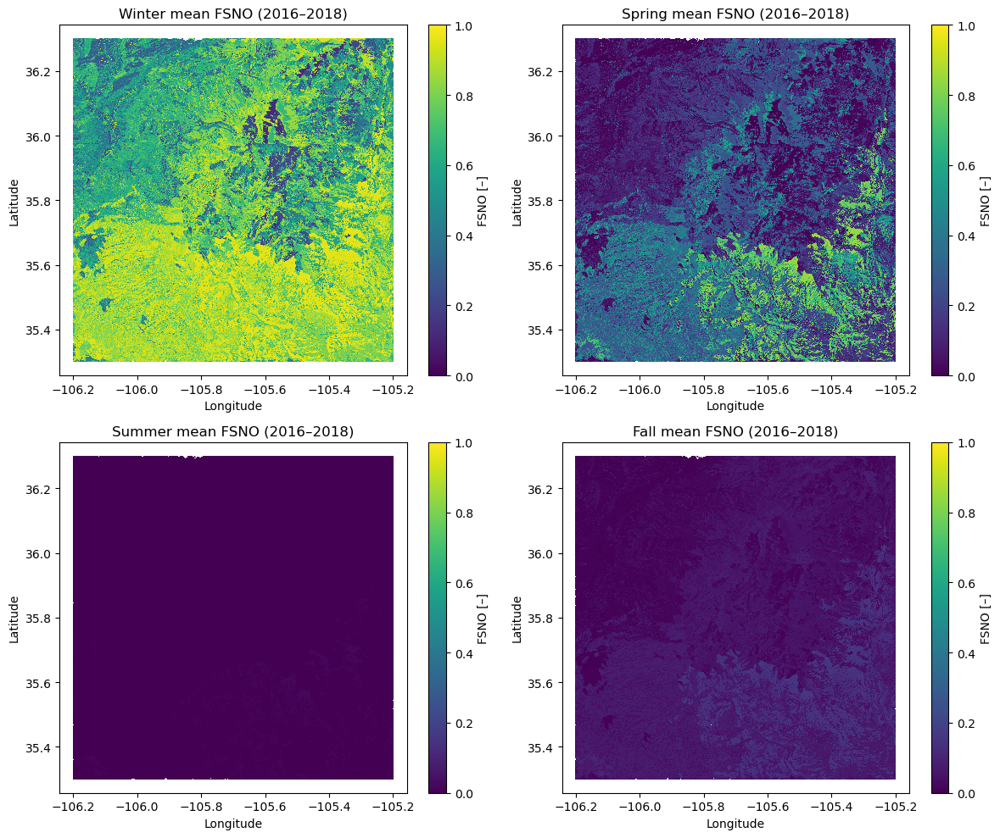

In [4]:
import numpy as np
import netCDF4 as nc
import pandas as pd
import matplotlib.pyplot as plt
import os
import matplotlib.colors as colors
import geospatialtools.gdal_tools as gdal_tools

# ----------------------------
# Paths
# ----------------------------
path_pp = "/scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/experiments/simulations/NLDAS_3h_Snow_Project3_pp_downscale/"
outputdir = "/scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/validation_plots/NLDAS_downscale_forcing_plots"
os.makedirs(outputdir, exist_ok=True)

fsno_file = path_pp + "output_data/1/2016-01-01.nc"

# ----------------------------
# Read HRU rasters
# ----------------------------
hrus = gdal_tools.read_raster(path_pp + "postprocess/hrus.vrt")
metad = gdal_tools.retrieve_metadata(path_pp + "postprocess/hrus.vrt")
cids = gdal_tools.read_raster(path_pp + "postprocess/cids.vrt")

buffer = 250

coord_xx0 = np.linspace(metad["minx"], metad["maxx"], metad["nx"])
coord_yy0 = np.linspace(metad["miny"], metad["maxy"], metad["ny"])

coords_x = coord_xx0[buffer:len(coord_xx0) - buffer + 1]
coords_y = coord_yy0[buffer:len(coord_yy0) - buffer + 1]

tmp = np.copy(hrus).astype(np.float32)
tmp[:] = -9999.0

def place_data(tmp, model, hrus, cids, cid_val):
    out = np.copy(tmp)
    nhru = len(model)

    for i in range(out.shape[0]):
        for j in range(out.shape[1]):
            hru = int(hrus[i, j])
            ucid = int(cids[i, j])

            if (ucid == cid_val) and (hru > 0) and (hru <= nhru):
                out[i, j] = model[hru - 1]

    return out

# ----------------------------
# Read FSNO from 2016–2018 rerun
# ----------------------------
fp = nc.Dataset(fsno_file)
grp = fp.groups["data"]
fsno = np.array(grp.variables["fsno"][:])   # (time, hru)
fp.close()

ntime = fsno.shape[0]
times = pd.date_range("2016-01-01 00:00:00", periods=ntime, freq="3H")

print("fsno shape:", fsno.shape)
print("time range:", times.min(), times.max())

# ----------------------------
# Diagnose HRU mismatch
# ----------------------------
mask_cid1 = (cids == 1) & (hrus > 0)
hru_vals = hrus[mask_cid1].astype(int)

print("min HRU in raster for cid=1:", hru_vals.min())
print("max HRU in raster for cid=1:", hru_vals.max())
print("unique HRUs in raster for cid=1:", len(np.unique(hru_vals)))

bad = np.unique(hru_vals[hru_vals > fsno.shape[1]])
print("number of invalid HRU ids:", len(bad))
print("first few invalid HRUs:", bad[:20])

# ----------------------------
# Seasonal definitions
# ----------------------------
seasons = ["Winter", "Spring", "Summer", "Fall"]
season_months = {
    "Winter": [12, 1, 2],
    "Spring": [3, 4, 5],
    "Summer": [6, 7, 8],
    "Fall":   [9, 10, 11],
}

# ----------------------------
# Plot 2x2 seasonal mean FSNO
# ----------------------------
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

fsno_norm = colors.Normalize(vmin=0.0, vmax=1.0)

for ax, season in zip(axes, seasons):
    mask = times.month.isin(season_months[season])
    fsno_season = fsno[mask, :]
    fsno_mean = np.nanmean(fsno_season, axis=0)

    final_map = place_data(tmp, fsno_mean, hrus, cids, 1)
    final_map = np.ma.masked_where(final_map == -9999.0, final_map)

    final_map = final_map[
        buffer:final_map.shape[0] - buffer + 1,
        buffer:final_map.shape[1] - buffer + 1
    ]

    im = ax.pcolormesh(
        coords_x,
        coords_y,
        np.flipud(final_map),
        cmap="viridis",
        norm=fsno_norm,
        shading="auto"
    )

    ax.set_title(f"{season} mean FSNO (2016–2018)")
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    fig.colorbar(im, ax=ax, label="FSNO [–]")

plt.tight_layout()
plt.savefig(
    os.path.join(outputdir, "NLDAS_Viridis_pp.png"),
    dpi=300,
    bbox_inches="tight"
)
plt.show()

fsno shape: (8744, 1000)
time range: 2016-01-01 00:00:00 2018-12-28 21:00:00
min HRU in raster for cid=1: 1
max HRU in raster for cid=1: 999
unique HRUs in raster for cid=1: 999
number of invalid HRU ids: 0
first few invalid HRUs: []


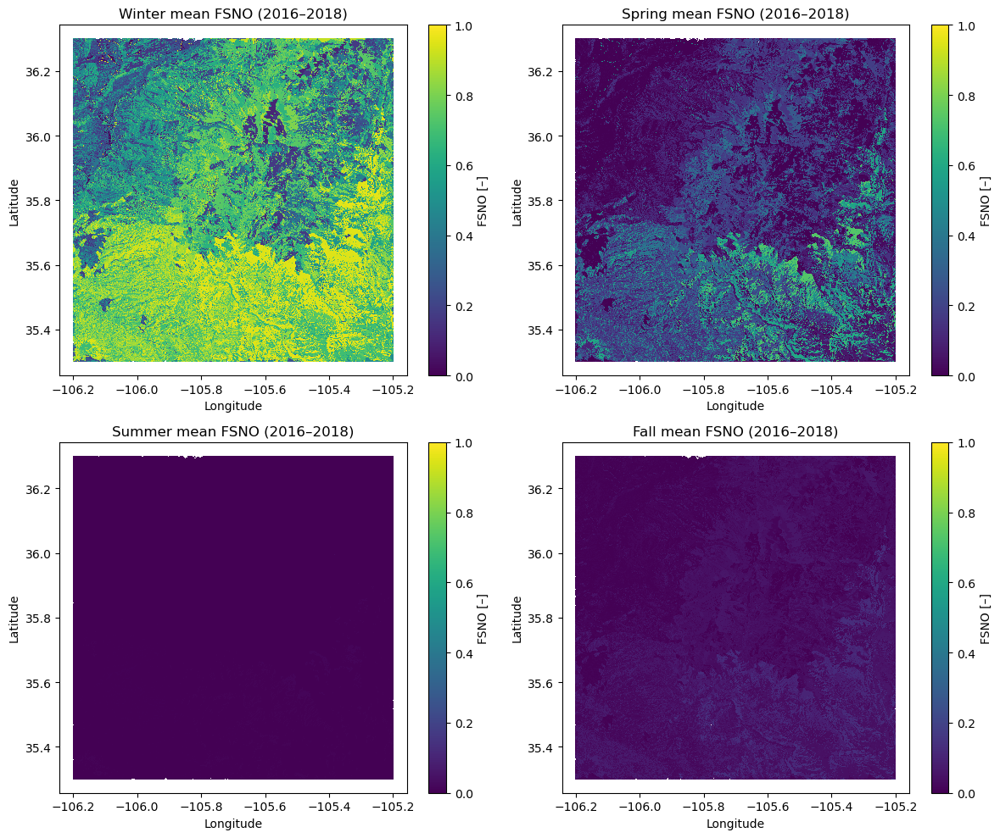

In [5]:
import numpy as np
import netCDF4 as nc
import pandas as pd
import matplotlib.pyplot as plt
import os
import matplotlib.colors as colors
import geospatialtools.gdal_tools as gdal_tools

# ----------------------------
# Paths
# ----------------------------
path_pp = "/scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/experiments/simulations/NLDAS_3h_Snow_Project3_3d_downscale/"
outputdir = "/scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/validation_plots/NLDAS_downscale_forcing_plots"
os.makedirs(outputdir, exist_ok=True)

fsno_file = path_pp + "output_data/1/2016-01-01.nc"

# ----------------------------
# Read HRU rasters
# ----------------------------
hrus = gdal_tools.read_raster(path_pp + "postprocess/hrus.vrt")
metad = gdal_tools.retrieve_metadata(path_pp + "postprocess/hrus.vrt")
cids = gdal_tools.read_raster(path_pp + "postprocess/cids.vrt")

buffer = 250

coord_xx0 = np.linspace(metad["minx"], metad["maxx"], metad["nx"])
coord_yy0 = np.linspace(metad["miny"], metad["maxy"], metad["ny"])

coords_x = coord_xx0[buffer:len(coord_xx0) - buffer + 1]
coords_y = coord_yy0[buffer:len(coord_yy0) - buffer + 1]

tmp = np.copy(hrus).astype(np.float32)
tmp[:] = -9999.0

def place_data(tmp, model, hrus, cids, cid_val):
    out = np.copy(tmp)
    nhru = len(model)

    for i in range(out.shape[0]):
        for j in range(out.shape[1]):
            hru = int(hrus[i, j])
            ucid = int(cids[i, j])

            if (ucid == cid_val) and (hru > 0) and (hru <= nhru):
                out[i, j] = model[hru - 1]

    return out

# ----------------------------
# Read FSNO from 2016–2018 rerun
# ----------------------------
fp = nc.Dataset(fsno_file)
grp = fp.groups["data"]
fsno = np.array(grp.variables["fsno"][:])   # (time, hru)
fp.close()

ntime = fsno.shape[0]
times = pd.date_range("2016-01-01 00:00:00", periods=ntime, freq="3H")

print("fsno shape:", fsno.shape)
print("time range:", times.min(), times.max())

# ----------------------------
# Diagnose HRU mismatch
# ----------------------------
mask_cid1 = (cids == 1) & (hrus > 0)
hru_vals = hrus[mask_cid1].astype(int)

print("min HRU in raster for cid=1:", hru_vals.min())
print("max HRU in raster for cid=1:", hru_vals.max())
print("unique HRUs in raster for cid=1:", len(np.unique(hru_vals)))

bad = np.unique(hru_vals[hru_vals > fsno.shape[1]])
print("number of invalid HRU ids:", len(bad))
print("first few invalid HRUs:", bad[:20])

# ----------------------------
# Seasonal definitions
# ----------------------------
seasons = ["Winter", "Spring", "Summer", "Fall"]
season_months = {
    "Winter": [12, 1, 2],
    "Spring": [3, 4, 5],
    "Summer": [6, 7, 8],
    "Fall":   [9, 10, 11],
}

# ----------------------------
# Plot 2x2 seasonal mean FSNO
# ----------------------------
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

fsno_norm = colors.Normalize(vmin=0.0, vmax=1.0)

for ax, season in zip(axes, seasons):
    mask = times.month.isin(season_months[season])
    fsno_season = fsno[mask, :]
    fsno_mean = np.nanmean(fsno_season, axis=0)

    final_map = place_data(tmp, fsno_mean, hrus, cids, 1)
    final_map = np.ma.masked_where(final_map == -9999.0, final_map)

    final_map = final_map[
        buffer:final_map.shape[0] - buffer + 1,
        buffer:final_map.shape[1] - buffer + 1
    ]

    im = ax.pcolormesh(
        coords_x,
        coords_y,
        np.flipud(final_map),
        cmap="viridis",
        norm=fsno_norm,
        shading="auto"
    )

    ax.set_title(f"{season} mean FSNO (2016–2018)")
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    fig.colorbar(im, ax=ax, label="FSNO [–]")

plt.tight_layout()
plt.savefig(
    os.path.join(outputdir, "NLDAS_Viridis_3d.png"),
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [11]:
import xarray as xr
import numpy as np

# --------------------------------------------------
# Paths
# --------------------------------------------------
base = "/scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/data/snow_experiment/data/cids/1/backup_forcing/"
nldas = base + "NLDAS_on_HBmetgrid_float32/"

# --------------------------------------------------
# Open files
# --------------------------------------------------
ds_p_mswx = xr.open_dataset(base + "precip.nc", decode_times=False)
ds_p_nldas = xr.open_dataset(nldas + "precip.nc", decode_times=False)

ds_t_mswx = xr.open_dataset(base + "tair.nc", decode_times=False)
ds_t_nldas = xr.open_dataset(nldas + "tair.nc", decode_times=False)

# --------------------------------------------------
# Variables
# --------------------------------------------------
p_m = ds_p_mswx["precip"]
p_n = ds_p_nldas["precip"]

t_m = ds_t_mswx["tair"]
t_n = ds_t_nldas["tair"]

# --------------------------------------------------
# Print attrs first
# --------------------------------------------------
print("MSWX precip attrs:")
print(p_m.attrs)
print("\nNLDAS precip attrs:")
print(p_n.attrs)

print("\nMSWX tair attrs:")
print(t_m.attrs)
print("\nNLDAS tair attrs:")
print(t_n.attrs)

# --------------------------------------------------
# Precip stats
# --------------------------------------------------
print("\n================ PRECIP =================")
print("MSWX precip shape:", p_m.shape, "dtype:", p_m.dtype)
print("NLDAS precip shape:", p_n.shape, "dtype:", p_n.dtype)

print("MSWX precip min :", float(np.nanmin(p_m.values)))
print("MSWX precip mean:", float(np.nanmean(p_m.values)))
print("MSWX precip max :", float(np.nanmax(p_m.values)))

print("NLDAS precip min :", float(np.nanmin(p_n.values)))
print("NLDAS precip mean:", float(np.nanmean(p_n.values)))
print("NLDAS precip max :", float(np.nanmax(p_n.values)))

# domain mean over all space at first timestep
print("\nMSWX precip first-step domain mean :", float(np.nanmean(p_m.isel(t=0).values)))
print("NLDAS precip first-step domain mean:", float(np.nanmean(p_n.isel(t=0).values)))

# approximate accumulated domain mean over whole period
# assumes precip is rate in mm/s and dt = 10800 s
dt = 10800.0
mswx_total = float(np.nanmean(p_m.values) * dt * p_m.shape[0])
nldas_total = float(np.nanmean(p_n.values) * dt * p_n.shape[0])

print("\nApprox MSWX total precip over period [mm]:", mswx_total)
print("Approx NLDAS total precip over period [mm]:", nldas_total)

# --------------------------------------------------
# Air temperature stats
# --------------------------------------------------
print("\n================ TAIR =================")
print("MSWX tair shape:", t_m.shape, "dtype:", t_m.dtype)
print("NLDAS tair shape:", t_n.shape, "dtype:", t_n.dtype)

print("MSWX tair min :", float(np.nanmin(t_m.values)))
print("MSWX tair mean:", float(np.nanmean(t_m.values)))
print("MSWX tair max :", float(np.nanmax(t_m.values)))

print("NLDAS tair min :", float(np.nanmin(t_n.values)))
print("NLDAS tair mean:", float(np.nanmean(t_n.values)))
print("NLDAS tair max :", float(np.nanmax(t_n.values)))

print("\nMSWX tair first-step domain mean :", float(np.nanmean(t_m.isel(t=0).values)))
print("NLDAS tair first-step domain mean:", float(np.nanmean(t_n.isel(t=0).values)))

# optional Celsius check
print("\nMSWX tair mean [C]:", float(np.nanmean(t_m.values) - 273.15))
print("NLDAS tair mean [C]:", float(np.nanmean(t_n.values) - 273.15))

# --------------------------------------------------
# Close
# --------------------------------------------------
ds_p_mswx.close()
ds_p_nldas.close()
ds_t_mswx.close()
ds_t_nldas.close()

MSWX precip attrs:
{'long_name': 'precip'}

NLDAS precip attrs:
{'long_name': 'precip', 'source': 'NLDAS Rainf aggregated from hourly to 3-hourly and interpolated to HydroBlocks grid'}

MSWX tair attrs:
{'long_name': 'tair'}

NLDAS tair attrs:
{'long_name': 'tair', 'units': 'K', 'description': '3-hour mean air temperature from NLDAS', 'source': 'NLDAS Tair aggregated from hourly to 3-hourly and interpolated to HydroBlocks grid'}

================ PRECIP =================
MSWX precip shape: (32128, 16, 16) dtype: float32
NLDAS precip shape: (32128, 16, 16) dtype: float32
MSWX precip min : 0.0
MSWX precip mean: 1.301888460147893e-05
MSWX precip max : 0.0035821758210659027
NLDAS precip min : -8.881784197001252e-16
NLDAS precip mean: 0.14049020409584045
NLDAS precip max : 53.54905319213867

MSWX precip first-step domain mean : 0.0
NLDAS precip first-step domain mean: 0.0

Approx MSWX total precip over period [mm]: 4517.323824344203
Approx NLDAS total precip over period [mm]: 48747628.19366

In [15]:
import xarray as xr
import numpy as np
import os

# --------------------------------------------------
# Paths
# --------------------------------------------------
base = "/scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/data/snow_experiment/data/cids/1/backup_forcing/"
nldas = base + "NLDAS_on_HBmetgrid_float32/"

fpath = nldas + "precip.nc"
outpath = nldas + "precip_corrected.nc"

# --------------------------------------------------
# Open
# --------------------------------------------------
ds = xr.open_dataset(fpath, decode_times=False)
da = ds["precip"]

print("Before correction:")
print("mean:", float(np.nanmean(da.values)))
print("max :", float(np.nanmax(da.values)))

# --------------------------------------------------
# Convert mm/3hr -> mm/s
# --------------------------------------------------
da_corr = (da / 10800.0).astype("float32")

da_corr.attrs = da.attrs.copy()
da_corr.attrs["units"] = "mm/s"
da_corr.attrs["conversion"] = "Converted from 3-hour accumulated precipitation to mm/s"

# --------------------------------------------------
# Save
# --------------------------------------------------
ds_out = da_corr.to_dataset(name="precip")

for coord in ["t", "lat", "lon"]:
    if coord in ds.coords:
        ds_out[coord].attrs = ds[coord].attrs.copy()

encoding = {"precip": {"dtype": "float32"}}
ds_out.to_netcdf(outpath, mode="w", encoding=encoding)

print("\nSaved corrected file to:")
print(outpath)

# --------------------------------------------------
# Check result
# --------------------------------------------------
ds_check = xr.open_dataset(outpath, decode_times=False)

print("\nAfter correction:")
print("mean:", float(np.nanmean(ds_check["precip"].values)))
print("max :", float(np.nanmax(ds_check["precip"].values)))

ds.close()
ds_check.close()

Before correction:
mean: 0.14049020409584045
max : 53.54905319213867

Saved corrected file to:
/scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/data/snow_experiment/data/cids/1/backup_forcing/NLDAS_on_HBmetgrid_float32/precip_corrected.nc

After correction:
mean: 1.3008354471821804e-05
max : 0.004958245437592268


swe shape: (8744, 1000)
time range: 2016-01-01 00:00:00 2018-12-28 21:00:00
min HRU in raster for cid=1: 1
max HRU in raster for cid=1: 999
unique HRUs in raster for cid=1: 999
number of invalid HRU ids: 0
first few invalid HRUs: []
SWE color scale min: 0.0
SWE color scale max: 116.77127


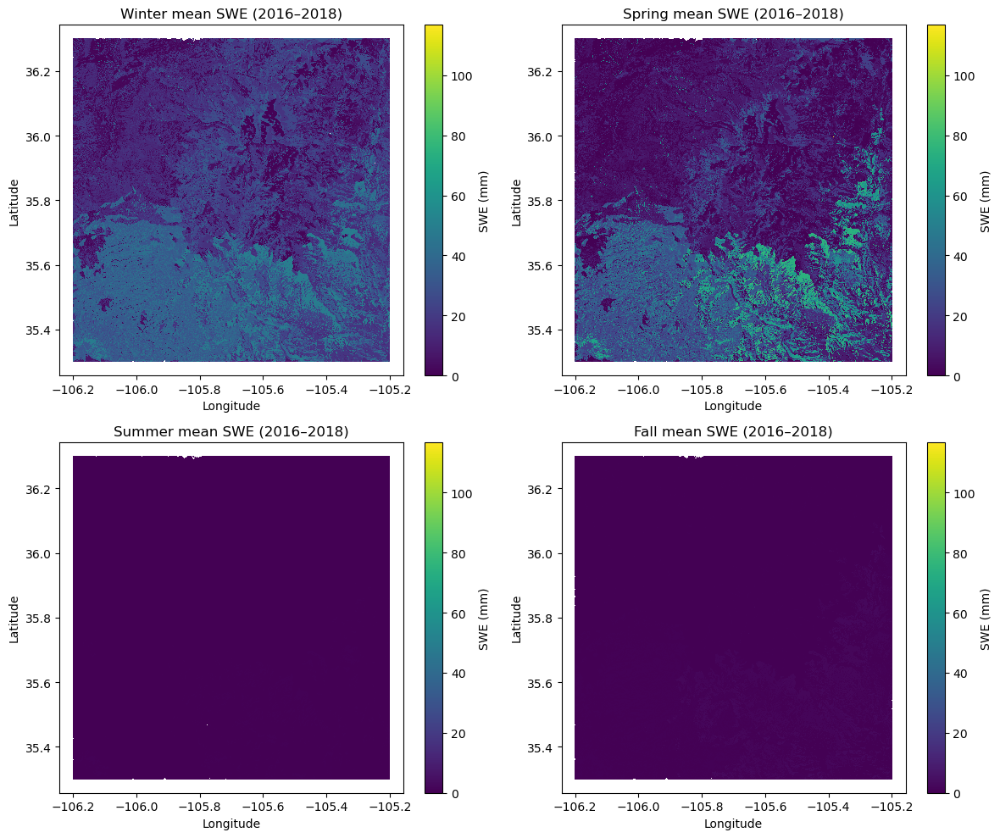

In [3]:
import numpy as np
import netCDF4 as nc
import pandas as pd
import matplotlib.pyplot as plt
import os
import matplotlib.colors as colors
import geospatialtools.gdal_tools as gdal_tools

# ----------------------------
# Paths
# ----------------------------
path_pp = "/scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/experiments/simulations/NLDAS_3h_Snow_Project3_pp_downscale/"
outputdir = "/scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/validation_plots/NLDAS_downscale_forcing_plots"
os.makedirs(outputdir, exist_ok=True)

swe_file = path_pp + "output_data/1/2016-01-01.nc"

# ----------------------------
# Read HRU rasters
# ----------------------------
hrus = gdal_tools.read_raster(path_pp + "postprocess/hrus.vrt")
metad = gdal_tools.retrieve_metadata(path_pp + "postprocess/hrus.vrt")
cids = gdal_tools.read_raster(path_pp + "postprocess/cids.vrt")

buffer = 250

coord_xx0 = np.linspace(metad["minx"], metad["maxx"], metad["nx"])
coord_yy0 = np.linspace(metad["miny"], metad["maxy"], metad["ny"])

coords_x = coord_xx0[buffer:len(coord_xx0) - buffer + 1]
coords_y = coord_yy0[buffer:len(coord_yy0) - buffer + 1]

tmp = np.copy(hrus).astype(np.float32)
tmp[:] = -9999.0

def place_data(tmp, model, hrus, cids, cid_val):
    out = np.copy(tmp)
    nhru = len(model)

    for i in range(out.shape[0]):
        for j in range(out.shape[1]):
            hru = int(hrus[i, j])
            ucid = int(cids[i, j])

            if (ucid == cid_val) and (hru > 0) and (hru <= nhru):
                out[i, j] = model[hru - 1]

    return out

# ----------------------------
# Read SWE
# ----------------------------
fp = nc.Dataset(swe_file)
grp = fp.groups["data"]
swe = np.array(grp.variables["swe"][:])   # (time, hru)
fp.close()

ntime = swe.shape[0]
times = pd.date_range("2016-01-01 00:00:00", periods=ntime, freq="3H")

print("swe shape:", swe.shape)
print("time range:", times.min(), times.max())

# ----------------------------
# Diagnose HRU mismatch
# ----------------------------
mask_cid1 = (cids == 1) & (hrus > 0)
hru_vals = hrus[mask_cid1].astype(int)

print("min HRU in raster for cid=1:", hru_vals.min())
print("max HRU in raster for cid=1:", hru_vals.max())
print("unique HRUs in raster for cid=1:", len(np.unique(hru_vals)))

bad = np.unique(hru_vals[hru_vals > swe.shape[1]])
print("number of invalid HRU ids:", len(bad))
print("first few invalid HRUs:", bad[:20])

# ----------------------------
# Seasonal definitions
# ----------------------------
seasons = ["Winter", "Spring", "Summer", "Fall"]
season_months = {
    "Winter": [12, 1, 2],
    "Spring": [3, 4, 5],
    "Summer": [6, 7, 8],
    "Fall":   [9, 10, 11],
}

# ----------------------------
# Get seasonal means first for shared color scale
# ----------------------------
seasonal_means = {}
all_vals = []

for season in seasons:
    mask = times.month.isin(season_months[season])
    swe_season = swe[mask, :]
    swe_mean = np.nanmean(swe_season, axis=0)
    seasonal_means[season] = swe_mean
    all_vals.append(swe_mean)

all_vals = np.concatenate(all_vals)
vmin = np.nanmin(all_vals)
vmax = np.nanmax(all_vals)

print("SWE color scale min:", vmin)
print("SWE color scale max:", vmax)

# ----------------------------
# Plot 2x2 seasonal mean SWE
# ----------------------------
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

swe_norm = colors.Normalize(vmin=vmin, vmax=vmax)

for ax, season in zip(axes, seasons):
    swe_mean = seasonal_means[season]

    final_map = place_data(tmp, swe_mean, hrus, cids, 1)
    final_map = np.ma.masked_where(final_map == -9999.0, final_map)

    final_map = final_map[
        buffer:final_map.shape[0] - buffer + 1,
        buffer:final_map.shape[1] - buffer + 1
    ]

    im = ax.pcolormesh(
        coords_x,
        coords_y,
        np.flipud(final_map),
        cmap="viridis",
        norm=swe_norm,
        shading="auto"
    )

    ax.set_title(f"{season} mean SWE (2016–2018)")
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    fig.colorbar(im, ax=ax, label="SWE (mm)")

plt.tight_layout()
plt.savefig(
    os.path.join(outputdir, "seasonal_mean_swe_2016_2018.png"),
    dpi=300,
    bbox_inches="tight"
)
plt.show()

fsno shape: (8744, 1000)
time range: 2016-01-01 00:00:00 2018-12-28 21:00:00
min HRU in raster for cid=1: 1
max HRU in raster for cid=1: 999
unique HRUs in raster for cid=1: 999
number of invalid HRU ids: 0
first few invalid HRUs: []


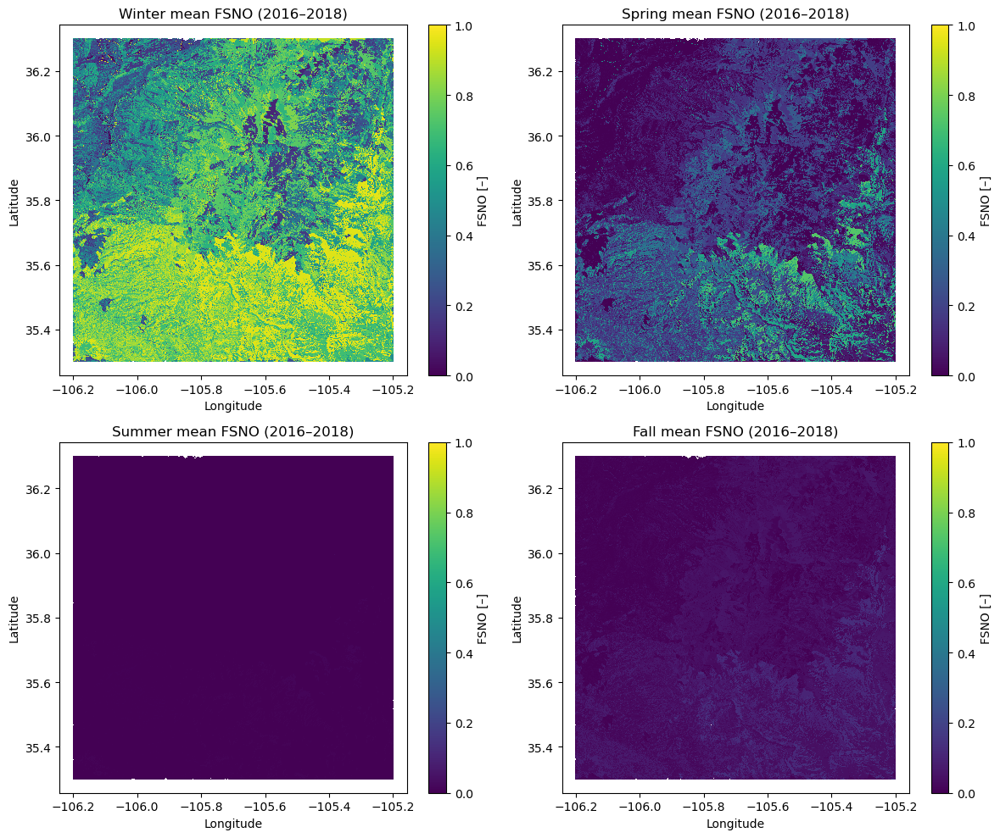

In [1]:
import numpy as np
import netCDF4 as nc
import pandas as pd
import matplotlib.pyplot as plt
import os
import matplotlib.colors as colors
import geospatialtools.gdal_tools as gdal_tools

# ----------------------------
# Paths
# ----------------------------
path_pp = "/scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/experiments/simulations/NLDAS_3h_Snow_Project3_3d_downscale/"
outputdir = "/scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/validation_plots/NLDAS_downscale_forcing_plots"
os.makedirs(outputdir, exist_ok=True)

fsno_file = path_pp + "output_data/1/2016-01-01.nc"

# ----------------------------
# Read HRU rasters
# ----------------------------
hrus = gdal_tools.read_raster(path_pp + "postprocess/hrus.vrt")
metad = gdal_tools.retrieve_metadata(path_pp + "postprocess/hrus.vrt")
cids = gdal_tools.read_raster(path_pp + "postprocess/cids.vrt")

buffer = 250

coord_xx0 = np.linspace(metad["minx"], metad["maxx"], metad["nx"])
coord_yy0 = np.linspace(metad["miny"], metad["maxy"], metad["ny"])

coords_x = coord_xx0[buffer:len(coord_xx0) - buffer + 1]
coords_y = coord_yy0[buffer:len(coord_yy0) - buffer + 1]

tmp = np.copy(hrus).astype(np.float32)
tmp[:] = -9999.0

def place_data(tmp, model, hrus, cids, cid_val):
    out = np.copy(tmp)
    nhru = len(model)

    for i in range(out.shape[0]):
        for j in range(out.shape[1]):
            hru = int(hrus[i, j])
            ucid = int(cids[i, j])

            if (ucid == cid_val) and (hru > 0) and (hru <= nhru):
                out[i, j] = model[hru - 1]

    return out

# ----------------------------
# Read FSNO from 2016–2018 rerun
# ----------------------------
fp = nc.Dataset(fsno_file)
grp = fp.groups["data"]
fsno = np.array(grp.variables["fsno"][:])   # (time, hru)
fp.close()

ntime = fsno.shape[0]
times = pd.date_range("2016-01-01 00:00:00", periods=ntime, freq="3H")

print("fsno shape:", fsno.shape)
print("time range:", times.min(), times.max())

# ----------------------------
# Diagnose HRU mismatch
# ----------------------------
mask_cid1 = (cids == 1) & (hrus > 0)
hru_vals = hrus[mask_cid1].astype(int)

print("min HRU in raster for cid=1:", hru_vals.min())
print("max HRU in raster for cid=1:", hru_vals.max())
print("unique HRUs in raster for cid=1:", len(np.unique(hru_vals)))

bad = np.unique(hru_vals[hru_vals > fsno.shape[1]])
print("number of invalid HRU ids:", len(bad))
print("first few invalid HRUs:", bad[:20])

# ----------------------------
# Seasonal definitions
# ----------------------------
seasons = ["Winter", "Spring", "Summer", "Fall"]
season_months = {
    "Winter": [12, 1, 2],
    "Spring": [3, 4, 5],
    "Summer": [6, 7, 8],
    "Fall":   [9, 10, 11],
}

# ----------------------------
# Plot 2x2 seasonal mean FSNO
# ----------------------------
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

fsno_norm = colors.Normalize(vmin=0.0, vmax=1.0)

for ax, season in zip(axes, seasons):
    mask = times.month.isin(season_months[season])
    fsno_season = fsno[mask, :]
    fsno_mean = np.nanmean(fsno_season, axis=0)

    final_map = place_data(tmp, fsno_mean, hrus, cids, 1)
    final_map = np.ma.masked_where(final_map == -9999.0, final_map)

    final_map = final_map[
        buffer:final_map.shape[0] - buffer + 1,
        buffer:final_map.shape[1] - buffer + 1
    ]

    im = ax.pcolormesh(
        coords_x,
        coords_y,
        np.flipud(final_map),
        cmap="viridis",
        norm=fsno_norm,
        shading="auto"
    )

    ax.set_title(f"{season} mean FSNO (2016–2018)")
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    fig.colorbar(im, ax=ax, label="FSNO [–]")

plt.tight_layout()
plt.savefig(
    os.path.join(outputdir, "NLDAS_Viridis_3d.png"),
    dpi=300,
    bbox_inches="tight"
)
plt.show()

fsno shape: (8744, 1000)
time range: 2016-01-01 00:00:00 2018-12-28 21:00:00
min HRU in raster for cid=1: 1
max HRU in raster for cid=1: 999
unique HRUs in raster for cid=1: 999
number of invalid HRU ids: 0
first few invalid HRUs: []


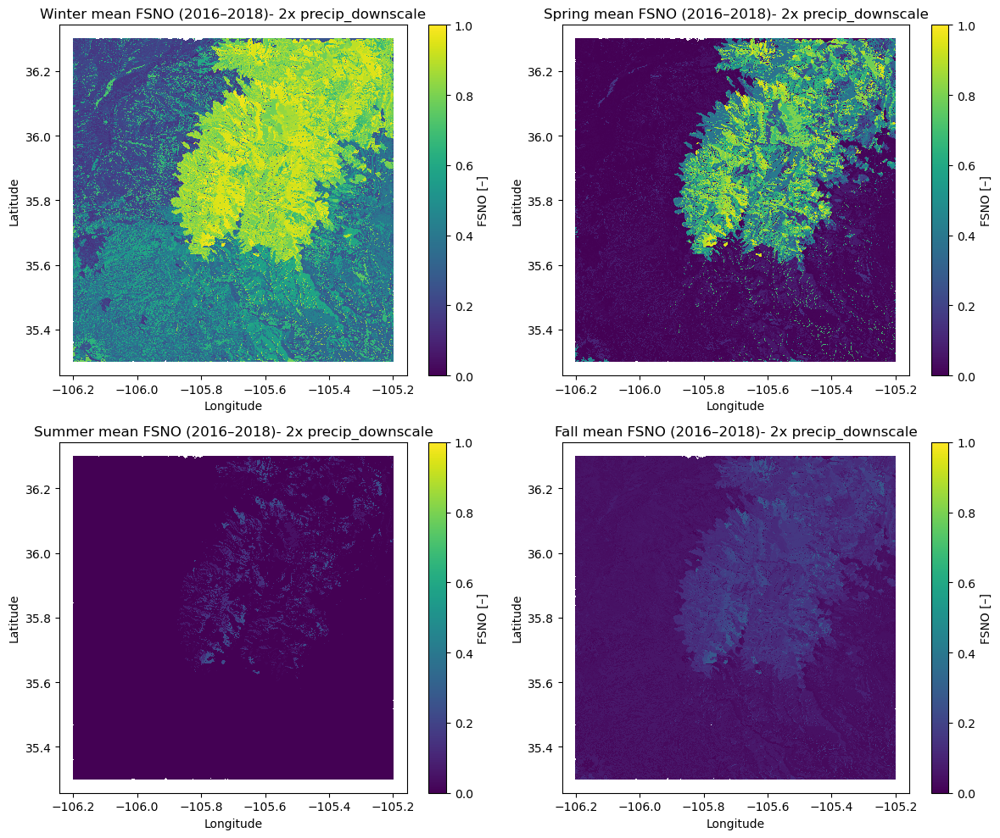

In [1]:
##### MSWX Downscaled

import numpy as np
import netCDF4 as nc
import pandas as pd
import matplotlib.pyplot as plt
import os
import matplotlib.colors as colors
import geospatialtools.gdal_tools as gdal_tools

# ----------------------------
# Paths
# ----------------------------
path_pp = "/scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/experiments/simulations/MSWX_3h_Snow_Project3_pp_downscale_new/"
outputdir = "/scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/validation_plots/MSWX_downscale_forcing_plots"
os.makedirs(outputdir, exist_ok=True)

fsno_file = path_pp + "output_data/1/2016-01-01.nc"

# ----------------------------
# Read HRU rasters
# ----------------------------
hrus = gdal_tools.read_raster(path_pp + "postprocess/hrus.vrt")
metad = gdal_tools.retrieve_metadata(path_pp + "postprocess/hrus.vrt")
cids = gdal_tools.read_raster(path_pp + "postprocess/cids.vrt")

buffer = 250

coord_xx0 = np.linspace(metad["minx"], metad["maxx"], metad["nx"])
coord_yy0 = np.linspace(metad["miny"], metad["maxy"], metad["ny"])

coords_x = coord_xx0[buffer:len(coord_xx0) - buffer + 1]
coords_y = coord_yy0[buffer:len(coord_yy0) - buffer + 1]

tmp = np.copy(hrus).astype(np.float32)
tmp[:] = -9999.0

def place_data(tmp, model, hrus, cids, cid_val):
    out = np.copy(tmp)
    nhru = len(model)

    for i in range(out.shape[0]):
        for j in range(out.shape[1]):
            hru = int(hrus[i, j])
            ucid = int(cids[i, j])

            if (ucid == cid_val) and (hru > 0) and (hru <= nhru):
                out[i, j] = model[hru - 1]

    return out

# ----------------------------
# Read FSNO from 2016–2018 rerun
# ----------------------------
fp = nc.Dataset(fsno_file)
grp = fp.groups["data"]
fsno = np.array(grp.variables["fsno"][:])   # (time, hru)
fp.close()

ntime = fsno.shape[0]
times = pd.date_range("2016-01-01 00:00:00", periods=ntime, freq="3H")

print("fsno shape:", fsno.shape)
print("time range:", times.min(), times.max())

# ----------------------------
# Diagnose HRU mismatch
# ----------------------------
mask_cid1 = (cids == 1) & (hrus > 0)
hru_vals = hrus[mask_cid1].astype(int)

print("min HRU in raster for cid=1:", hru_vals.min())
print("max HRU in raster for cid=1:", hru_vals.max())
print("unique HRUs in raster for cid=1:", len(np.unique(hru_vals)))

bad = np.unique(hru_vals[hru_vals > fsno.shape[1]])
print("number of invalid HRU ids:", len(bad))
print("first few invalid HRUs:", bad[:20])

# ----------------------------
# Seasonal definitions
# ----------------------------
seasons = ["Winter", "Spring", "Summer", "Fall"]
season_months = {
    "Winter": [12, 1, 2],
    "Spring": [3, 4, 5],
    "Summer": [6, 7, 8],
    "Fall":   [9, 10, 11],
}

# ----------------------------
# Plot 2x2 seasonal mean FSNO
# ----------------------------
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

fsno_norm = colors.Normalize(vmin=0.0, vmax=1.0)

for ax, season in zip(axes, seasons):
    mask = times.month.isin(season_months[season])
    fsno_season = fsno[mask, :]
    fsno_mean = np.nanmean(fsno_season, axis=0)

    final_map = place_data(tmp, fsno_mean, hrus, cids, 1)
    final_map = np.ma.masked_where(final_map == -9999.0, final_map)

    final_map = final_map[
        buffer:final_map.shape[0] - buffer + 1,
        buffer:final_map.shape[1] - buffer + 1
    ]

    im = ax.pcolormesh(
        coords_x,
        coords_y,
        np.flipud(final_map),
        cmap="viridis",
        norm=fsno_norm,
        shading="auto"
    )

    ax.set_title(f"{season} mean FSNO (2016–2018)- 2x precip_downscale")
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    fig.colorbar(im, ax=ax, label="FSNO [–]")

plt.tight_layout()
plt.savefig(
    os.path.join(outputdir, "MSWX_downscaled_Viridis_pp_new.png"),
    dpi=300,
    bbox_inches="tight"
)
plt.show()